# Chess Resources — EDA y Pipeline de Recategorización
## `chess_resources_v3.csv` · 1472 recursos · 28 features

**Autor:** Eneko  
**Descripción:** Análisis exploratorio completo del catálogo de materiales de ajedrez (cursos, vídeos y libros) obtenidos de Modern Chess, YouTube, Chessable, Telegram Community, Udemy y fuentes manuales. El notebook culmina con un pipeline de recategorización de nivel basado en señales numéricas y semánticas, orientado a preparar el dataset para el sistema de recomendación ML.

> **ℹ️ Nota de versión:** Actualizado con la integración de nuevas fuentes (+398 recursos respecto a v2).
> Incluye recursos de **Telegram** (227) y **Chessable** (84) previamente no mergeados.

---

### Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Importaciones y configuración global |
| 2 | Carga de datos y feature engineering base |
| 3 | Vista general: dtypes, nulos, shape |
| 4 | Distribuciones categóricas |
| 5 | Distribuciones numéricas |
| 6 | Feature engineering — Richness Score |
| 7 | Heatmap de correlaciones |
| 8 | Pivot tables y distribuciones cruzadas |
| 9 | Cobertura de aperturas |
| 10 | Análisis de precio y gratuidad |
| 11 | Estandarización y test de normalidad |
| 12 | Pairplot y scatter seleccionados |
| 13 | Conclusiones y features para el recomendador |
| 14 | Preparación del DataFrame para ML |
| 15 | Pipeline de recategorización de nivel (3 tiers) |


---
## 1. Importaciones y Configuración Global

Se cargan todas las librerías necesarias y se define el estilo visual unificado para todas las figuras del notebook.  
La paleta oscura facilita la lectura en presentaciones y es consistente con el resto del proyecto.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# ──────────────────────────────────────────────────────────────────────────────
# RUTAS DEL PROYECTO
# ──────────────────────────────────────────────────────────────────────────────
PROJECT_ROOT = r"C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML"
CSV_DIR      = os.path.join(PROJECT_ROOT, "src", "data", "CSV")
IMG_DIR      = os.path.join(PROJECT_ROOT, "resources", "img")

# Archivo principal — catálogo unificado con todas las fuentes integradas
# Versión actual: 1472 recursos (Modern Chess + YouTube + Chessable + Telegram + otros)
CSV_MASTER      = os.path.join(CSV_DIR, "chess_resources_v3.csv")
CSV_3TIER       = os.path.join(CSV_DIR, "chess_resources_3tier.csv")  # output del pipeline §15
IMG_BALANCE     = os.path.join(IMG_DIR, "level_balance_analysis.png")

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────
# ESTILO VISUAL GLOBAL
# Paleta oscura uniforme para todas las figuras del notebook.
# ──────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d0f14',
    'axes.facecolor':    '#141720',
    'axes.edgecolor':    '#2a2f45',
    'axes.labelcolor':   '#e2e6f0',
    'xtick.color':       '#7a82a0',
    'ytick.color':       '#7a82a0',
    'text.color':        '#e2e6f0',
    'grid.color':        '#1c2030',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'font.family':       'monospace',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
    'figure.titlesize':  15,
})

PALETTE     = ['#4f8ef7','#f7c94f','#4ff7a8','#f74f7a','#af4ff7','#f7884f','#4ff0f7','#f74fb8','#7a82a0']
LEVEL_ORDER = ['beginner', 'intermediate', 'advanced', 'expert']

print('✅ Setup completo.')
print(f'   CSV maestro → {CSV_MASTER}')
print(f'   Imágenes    → {IMG_DIR}')


✅ Setup completo.
   CSV maestro → C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\data\CSV\chess_resources_v3.csv
   Imágenes    → C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\resources\img


---
## 2. Carga de Datos y Feature Engineering Base

Se carga el CSV maestro y se añaden tres features derivadas que se usarán a lo largo del EDA:

| Feature | Definición |
|---|---|
| `richness` | Suma de `has_video + has_pgn + has_exercises + has_spaced_rep` (0–4) |
| `level_range` | `level_max − level_min`: amplitud del rango de Elo sugerido |
| `is_opening` | Booleano: el recurso es de tipo apertura |

`level_tier` se convierte a `Categorical` ordenada para respetar el orden natural en los plots.

In [2]:
df = pd.read_csv(CSV_MASTER)

# Features derivadas básicas
df['richness']   = df[['has_video','has_pgn','has_exercises','has_spaced_rep']].fillna(0).sum(axis=1)
df['level_range'] = df['level_max'] - df['level_min']
df['is_opening']  = (df['course_type'] == 'opening').astype(int)

# Categoría ordenada para respetar el orden lógico en gráficos
df['level_tier'] = pd.Categorical(df['level_tier'], categories=LEVEL_ORDER, ordered=True)

print(f"Shape: {df.shape}")
print(f"Fuentes: {df['source'].nunique()} | Recursos únicos: {df['resource_id'].nunique()}")
df.head(3)


Shape: (1472, 31)
Fuentes: 15 | Recursos únicos: 1472


,resource_id,source,title,url,resource_type,format,course_type,openings,color,author,author_title,level_min,level_max,level_tier,duration_min,...,is_free,has_video,has_pgn,has_exercises,has_spaced_rep,rating_score,views_yt,pub_date,description,level_tier_original,level_tier_source,level_tier_new,richness,level_range,is_opening
0,mc__dreev_deep_caro_kann_repertoire_for_blac,modern_chess,Dreev Deep Caro-Kann - Repertoire for Black af...,https://www.modern-chess.com/course/dreev-deep...,course,video,opening,Caro-Kann Defense|1.e4,Black,"GMAlexey Dreev, GMPier Luigi Basso",GM,1200.00,3000.00,intermediate,154.00,...,0,1,1.00,1.00,1.00,NaN,NaN,NaN,"May 5, 2026Caro-Kann Defense1.e4",intermediate,fallback_lmin,intermediate,4.00,1800.00,1
1,mc__dragon_for_black,modern_chess,Dragon for BlackPremiumDiscounted,https://www.modern-chess.com/course/dragon-for...,course,video,opening,Sicilian Defense|1.e4,Black,GMSina Movahed,GM,2300.00,3000.00,expert,251.00,...,0,1,1.00,1.00,1.00,NaN,NaN,NaN,"For decades, the Dragon existed in uncertain t...",expert,range_only,expert,4.00,700.00,1
2,mc__chebanenko_slav_for_black_part_1,modern_chess,Chebanenko Slav for Black - Part 1,https://www.modern-chess.com/course/chebanenko...,course,video,opening,Slav Defense|1.d4,Black,"GMPier Luigi Basso, GMVladimir Malakhov",GM,2300.00,3000.00,expert,169.00,...,0,1,1.00,1.00,1.00,NaN,NaN,NaN,"May 3, 2026Slav Defense1.d4",expert,range_only,expert,4.00,700.00,1


---
## 3. Vista General del Dataset

Se inspeccionan los tipos de dato y el porcentaje de valores nulos por columna.  
El mapa de nulos usa un semáforo de colores para priorizar acciones:  
🔴 >80% → eliminar · 🟠 40–80% → decidir · 🟡 10–40% → imputar · 🟢 <10% → OK

In [3]:
# Tabla de tipos de dato y porcentaje de nulos por columna
null_pct = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
dtype_df = df.dtypes.reset_index()
dtype_df.columns = ['columna', 'dtype']
dtype_df['nulos_%'] = dtype_df['columna'].map(null_pct)
print(dtype_df.to_string(index=False))


            columna    dtype  nulos_%
        resource_id   object     0.00
             source   object     0.00
              title   object     0.00
                url   object     0.00
      resource_type   object     0.00
             format   object     0.00
        course_type   object     0.00
           openings   object    43.10
              color   object     0.00
             author   object    21.50
       author_title   object    41.70
          level_min  float64    20.20
          level_max  float64    20.20
         level_tier category     0.00
       duration_min  float64    57.80
          price_eur  float64    76.20
            is_free    int64     0.00
          has_video    int64     0.00
            has_pgn  float64     5.40
      has_exercises  float64     5.40
     has_spaced_rep  float64     5.40
       rating_score  float64    91.50
           views_yt  float64    87.70
           pub_date   object    73.80
        description   object     0.00
level_tier_o

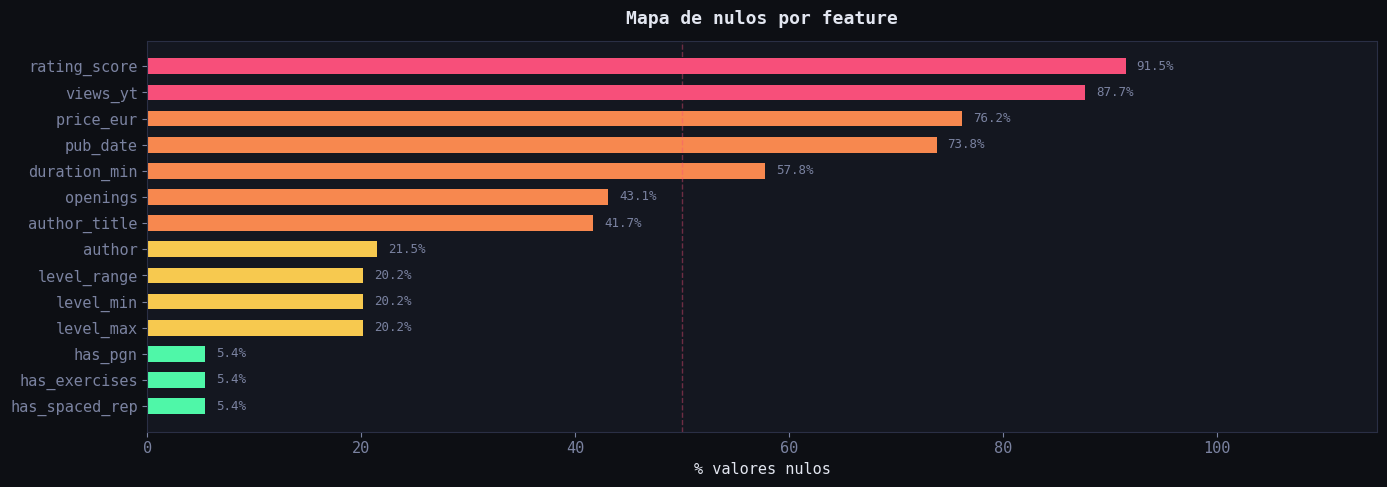


🔴 Eliminar del modelo (>90% nulos):
['rating_score']

🟡 Requieren imputación (10-90% nulos):
['views_yt', 'price_eur', 'pub_date', 'duration_min', 'openings', 'author_title', 'author', 'level_max', 'level_min', 'level_range']


In [4]:
# Mapa visual de nulos con escala de color semáforo
fig, ax = plt.subplots(figsize=(14, 5))

null_pct_sorted = null_pct[null_pct > 0].sort_values(ascending=True)
colors = ['#f74f7a' if v > 80 else '#f7884f' if v > 40 else '#f7c94f' if v > 10 else '#4ff7a8'
          for v in null_pct_sorted]

bars = ax.barh(null_pct_sorted.index, null_pct_sorted.values, color=colors, height=0.6)
ax.set_xlabel('% valores nulos')
ax.set_title('Mapa de nulos por feature')
ax.axvline(x=50, color='#f74f7a', linestyle='--', alpha=0.4, lw=1)

for bar, val in zip(bars, null_pct_sorted.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color='#7a82a0')

ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

print("\n🔴 Eliminar del modelo (>90% nulos):")
print(list(null_pct[null_pct > 90].index))
print("\n🟡 Requieren imputación (10-90% nulos):")
print(list(null_pct[(null_pct > 10) & (null_pct <= 90)].index))


---
## 4. Distribuciones Categóricas

Distribución de las seis variables categóricas principales.  
La tabla pivot `source × level_tier` revela los sesgos de representación por fuente
(Modern Chess domina con ~77% del catálogo).

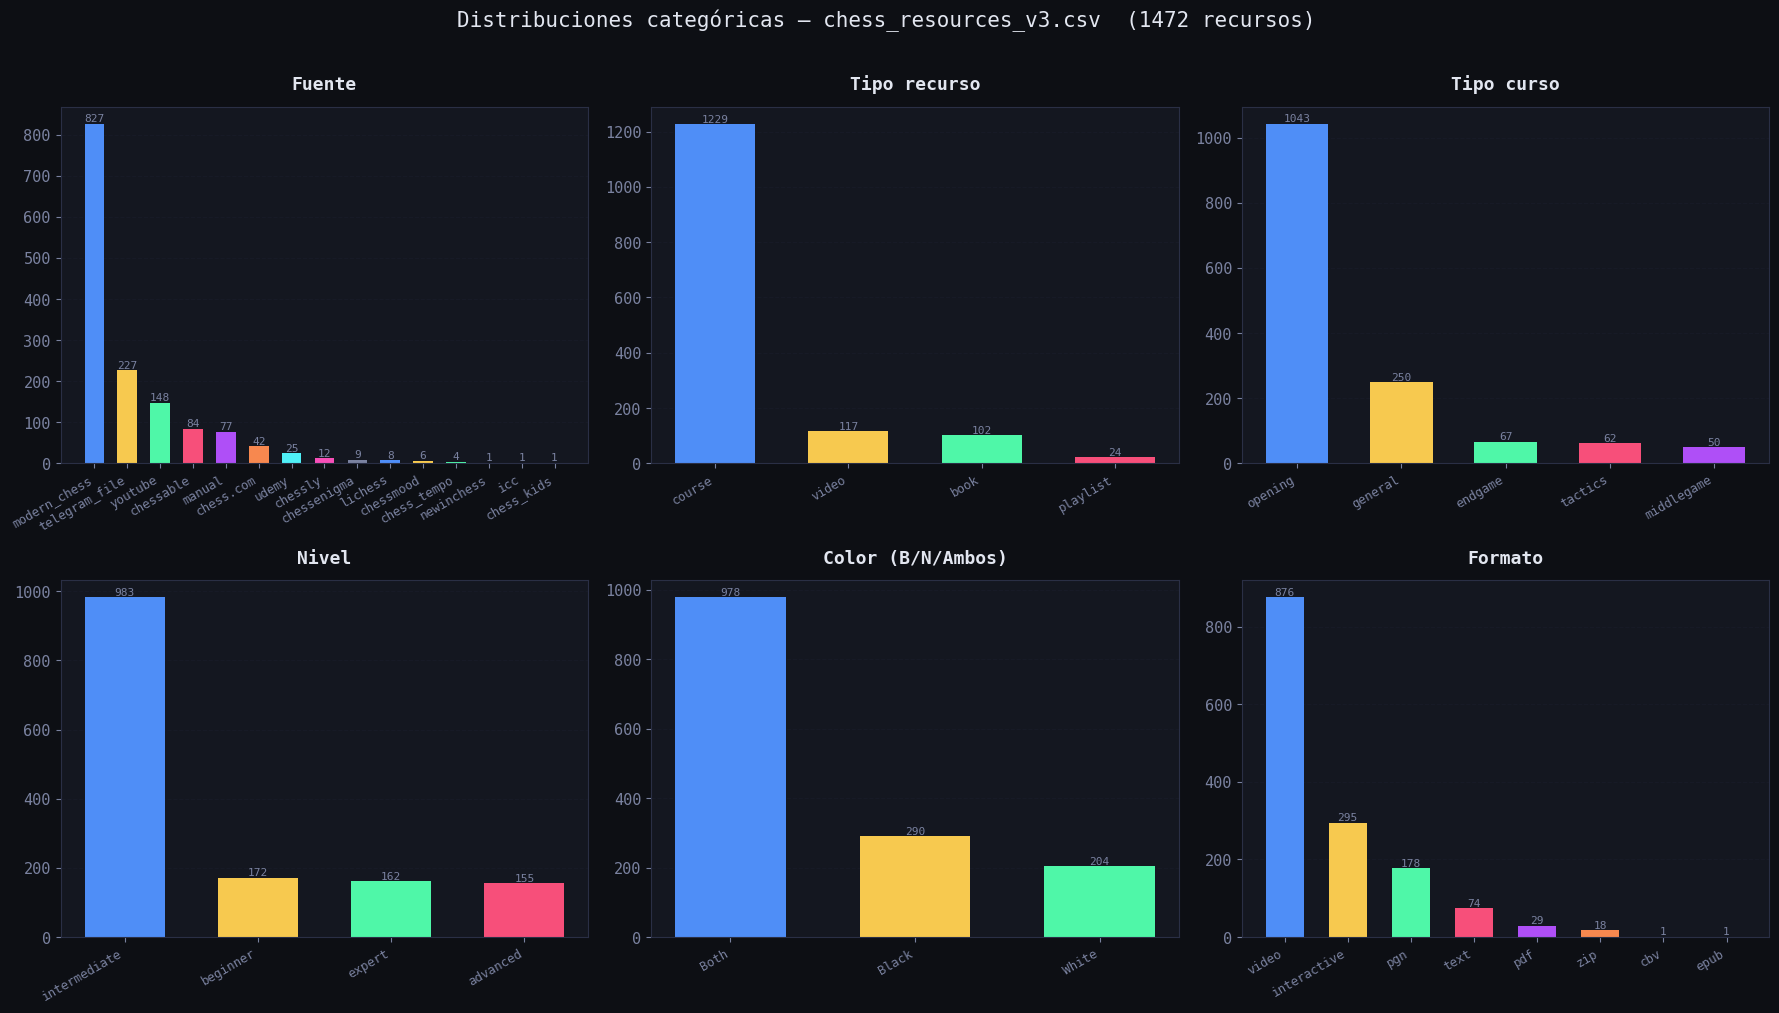

In [5]:
# Grid 2×3: distribución de las 6 variables categóricas clave
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Distribuciones categóricas — chess_resources_v3.csv  ({len(df)} recursos)', y=1.01)

cat_vars = [
    ('source',        'Fuente'),
    ('resource_type', 'Tipo recurso'),
    ('course_type',   'Tipo curso'),
    ('level_tier',    'Nivel'),
    ('color',         'Color (B/N/Ambos)'),
    ('format',        'Formato'),
]

for ax, (col, title) in zip(axes.flat, cat_vars):
    counts = df[col].value_counts()
    bars = ax.bar(range(len(counts)), counts.values,
                  color=PALETTE[:len(counts)], width=0.6)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(title)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontsize=8, color='#7a82a0')

plt.tight_layout()
plt.show()


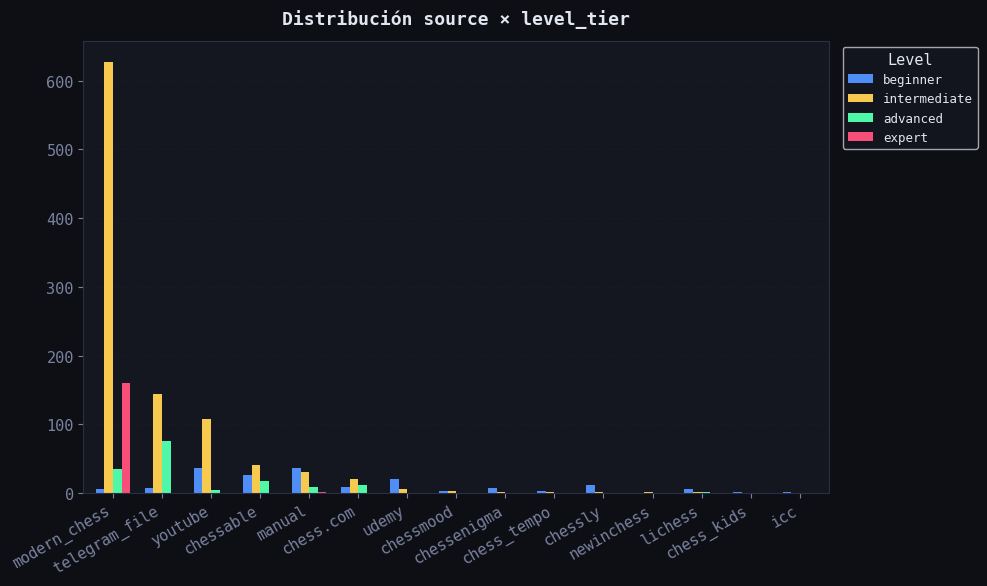

level_tier     beginner  intermediate  advanced  expert
source                                                 
modern_chess          5           627        35     160
telegram_file         7           144        76       0
youtube              37           107         4       0
chessable            26            40        18       0
manual               36            30         9       2
chess.com             9            21        12       0
udemy                20             5         0       0
chessmood             3             3         0       0
chessenigma           7             2         0       0
chess_tempo           3             1         0       0
chessly              11             1         0       0
newinchess            0             1         0       0
lichess               6             1         1       0
chess_kids            1             0         0       0
icc                   1             0         0       0


In [6]:
# Pivot source × level_tier: detecta qué fuentes cubren qué nivel
pivot_src = df.groupby(['source','level_tier']).size().unstack(fill_value=0)
pivot_src = pivot_src.sort_values('intermediate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_src.plot(kind='bar', ax=ax, color=PALETTE[:4], width=0.7, edgecolor='none')
ax.set_title('Distribución source × level_tier')
ax.set_xlabel('')
ax.set_xticklabels(pivot_src.index, rotation=30, ha='right')
ax.legend(title='Level', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print(pivot_src.to_string())


---
## 5. Distribuciones Numéricas

Histogramas con media/mediana y coeficiente de asimetría (skew) para las variables continuas.  
Los boxplots por nivel revelan si las variables discriminan bien entre tiers.  
Los `views_yt` siguen una distribución log-normal, lo que justifica aplicar `log10` antes del modelado.

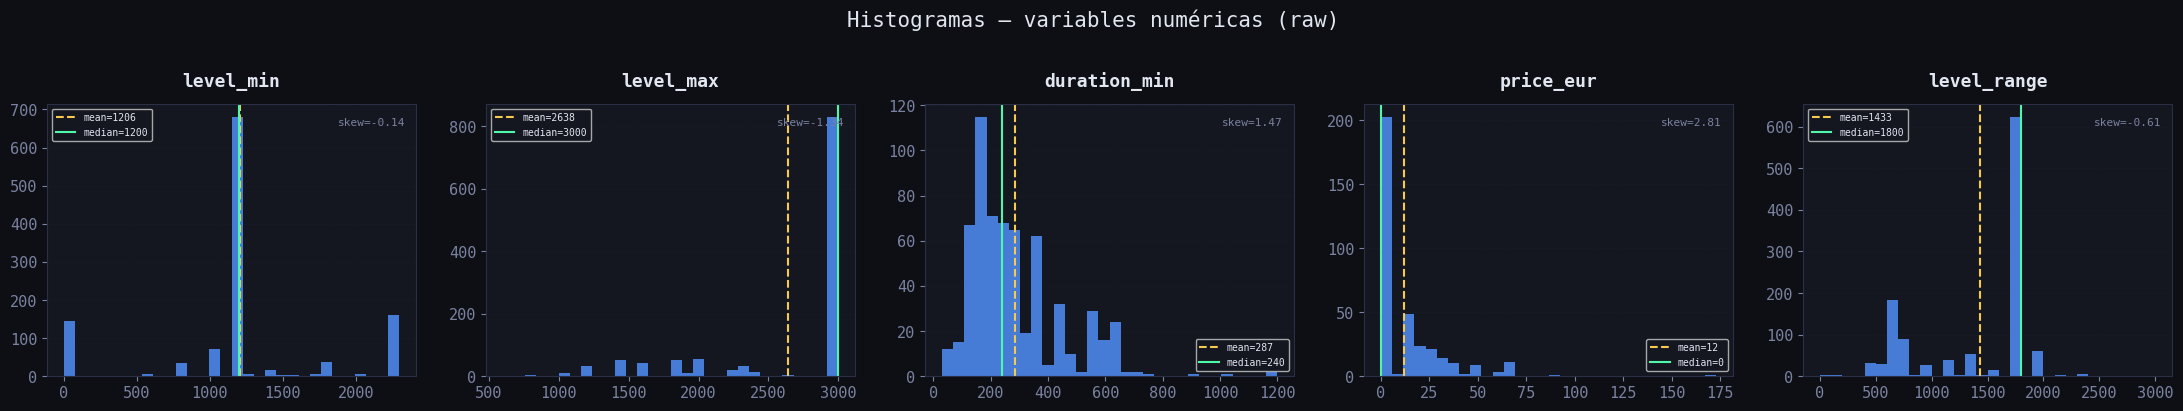

In [7]:
# Histogramas con media, mediana y skew para las 5 variables numéricas clave
num_cols = ['level_min', 'level_max', 'duration_min', 'price_eur', 'level_range']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Histogramas — variables numéricas (raw)', y=1.02)

for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    ax.hist(data, bins=30, color='#4f8ef7', edgecolor='none', alpha=0.85)
    ax.axvline(data.mean(),   color='#f7c94f', lw=1.5, linestyle='--', label=f'mean={data.mean():.0f}')
    ax.axvline(data.median(), color='#4ff7a8', lw=1.5, linestyle='-',  label=f'median={data.median():.0f}')
    ax.set_title(col)
    ax.legend(fontsize=7)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    sk = stats.skew(data)
    ax.text(0.97, 0.95, f'skew={sk:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#7a82a0')

plt.tight_layout()
plt.show()


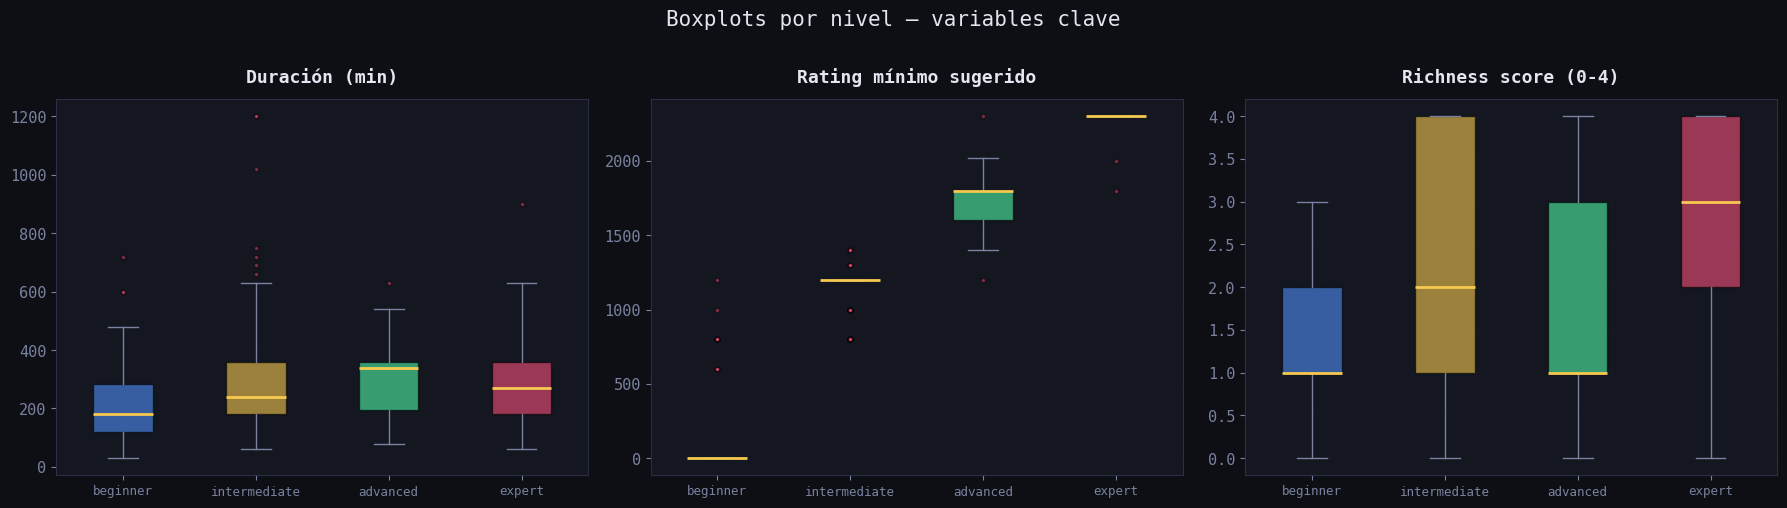

In [8]:
# Boxplots por nivel para detectar si las variables discriminan entre tiers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Boxplots por nivel — variables clave', y=1.01)

box_vars = [
    ('duration_min', 'Duración (min)'),
    ('level_min',    'Rating mínimo sugerido'),
    ('richness',     'Richness score (0-4)'),
]

for ax, (col, title) in zip(axes, box_vars):
    data_by_level = [df[df['level_tier']==lvl][col].dropna() for lvl in LEVEL_ORDER]
    bp = ax.boxplot(data_by_level, patch_artist=True, notch=False,
                    medianprops=dict(color='#f7c94f', lw=2),
                    whiskerprops=dict(color='#7a82a0'),
                    capprops=dict(color='#7a82a0'),
                    flierprops=dict(marker='o', markerfacecolor='#f74f7a', markersize=3, alpha=0.5))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticklabels(LEVEL_ORDER, fontsize=9)
    ax.set_title(title)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


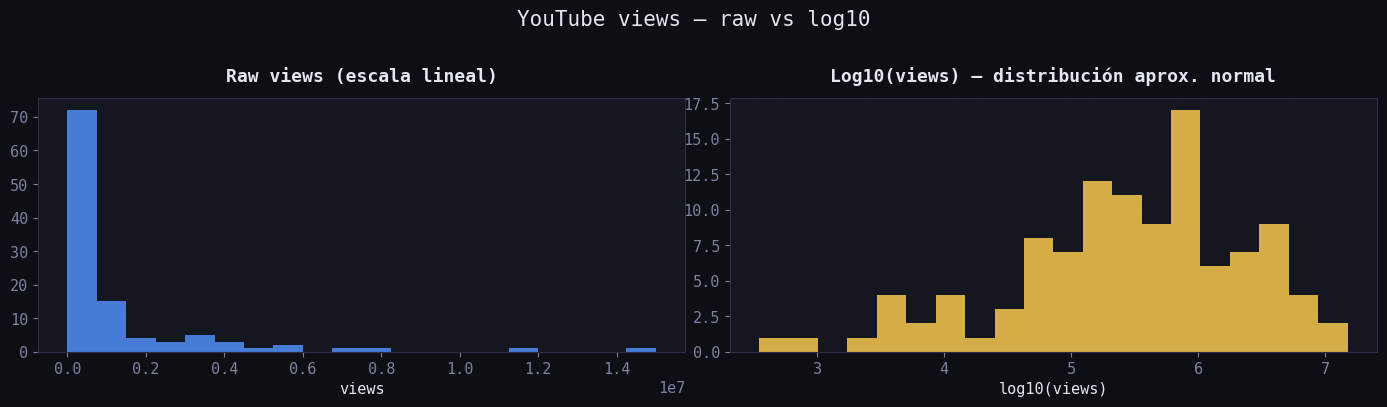

n vídeos: 109
Mediana: 347,768 | Max: 15,000,000
Skew raw: 3.54 | Skew log10: -0.68


In [9]:
# YouTube views: comparación raw vs log10 para justificar la transformación log
# Filtrar NaN y ceros: log10(0) = -inf → error en matplotlib
# Los nuevos recursos (Telegram, Chessable) tienen views_yt=0, no NaN
yt = df[(df['views_yt'].notna()) & (df['views_yt'] > 0)].copy()
yt['log_views'] = np.log10(yt['views_yt'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('YouTube views — raw vs log10', y=1.01)

axes[0].hist(yt['views_yt'], bins=20, color='#4f8ef7', edgecolor='none', alpha=0.85)
axes[0].set_title('Raw views (escala lineal)')
axes[0].set_xlabel('views')

axes[1].hist(yt['log_views'], bins=20, color='#f7c94f', edgecolor='none', alpha=0.85)
axes[1].set_title('Log10(views) — distribución aprox. normal')
axes[1].set_xlabel('log10(views)')

for ax in axes:
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"n vídeos: {len(yt)}")
print(f"Mediana: {yt['views_yt'].median():,.0f} | Max: {yt['views_yt'].max():,.0f}")
print(f"Skew raw: {stats.skew(yt['views_yt']):.2f} | Skew log10: {stats.skew(yt['log_views']):.2f}")


---
## 6. Feature Engineering — Richness Score

`richness ∈ [0, 4]` agrega la presencia de los cuatro formatos multimedia de un recurso.  
Es una de las features más útiles para el recomendador porque captura la preferencia de formato del usuario.  
El heatmap `richness × level` detecta si los recursos de nivel avanzado tienden a ser más ricos en formato.

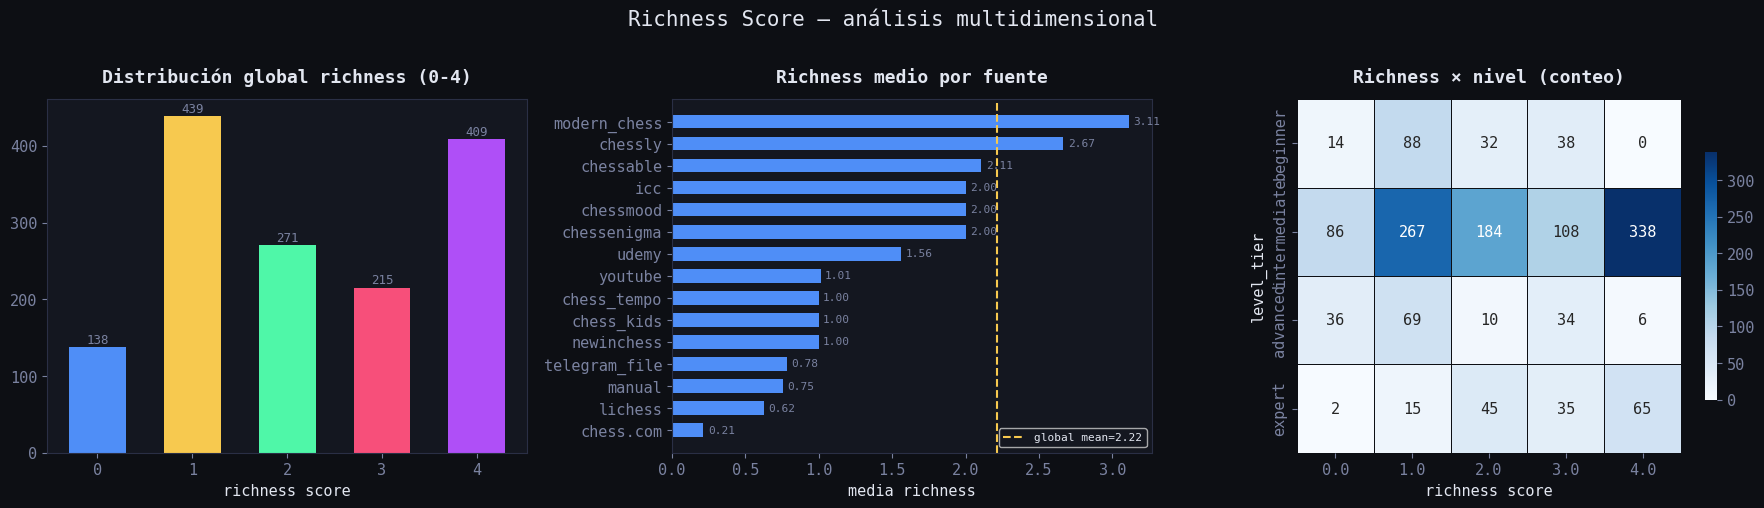

In [10]:
# Distribución global, por fuente y heatmap richness × nivel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Richness Score — análisis multidimensional', y=1.01)

# 1. Distribución global
counts = df['richness'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=PALETTE[:5], width=0.6)
axes[0].set_title('Distribución global richness (0-4)')
axes[0].set_xlabel('richness score')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(idx, val + 5, str(val), ha='center', fontsize=9, color='#7a82a0')

# 2. Richness medio por fuente (barras horizontales ordenadas)
rich_src = df.groupby('source')['richness'].mean().sort_values(ascending=True)
axes[1].barh(rich_src.index, rich_src.values, color='#4f8ef7', height=0.6)
axes[1].set_title('Richness medio por fuente')
axes[1].set_xlabel('media richness')
axes[1].axvline(x=df['richness'].mean(), color='#f7c94f', lw=1.5, linestyle='--',
                label=f'global mean={df["richness"].mean():.2f}')
axes[1].legend(fontsize=8)
for bar, val in zip(axes[1].patches, rich_src.values):
    axes[1].text(val + 0.03, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=8, color='#7a82a0')

# 3. Heatmap richness × nivel para detectar patrones cruzados
pivot_rich = df.groupby(['level_tier','richness']).size().unstack(fill_value=0)
sns.heatmap(pivot_rich, ax=axes[2], cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, linecolor='#0d0f14', cbar_kws={'shrink': 0.7})
axes[2].set_title('Richness × nivel (conteo)')
axes[2].set_xlabel('richness score')

plt.tight_layout()
plt.show()


---
## 7. Heatmap de Correlaciones

Matriz de correlación de Pearson (triángulo inferior) para las 14 variables numéricas.  
Las correlaciones más relevantes para el recomendador son las que vinculan `level_min` con `level_tier_enc` y `richness` con `has_*`.

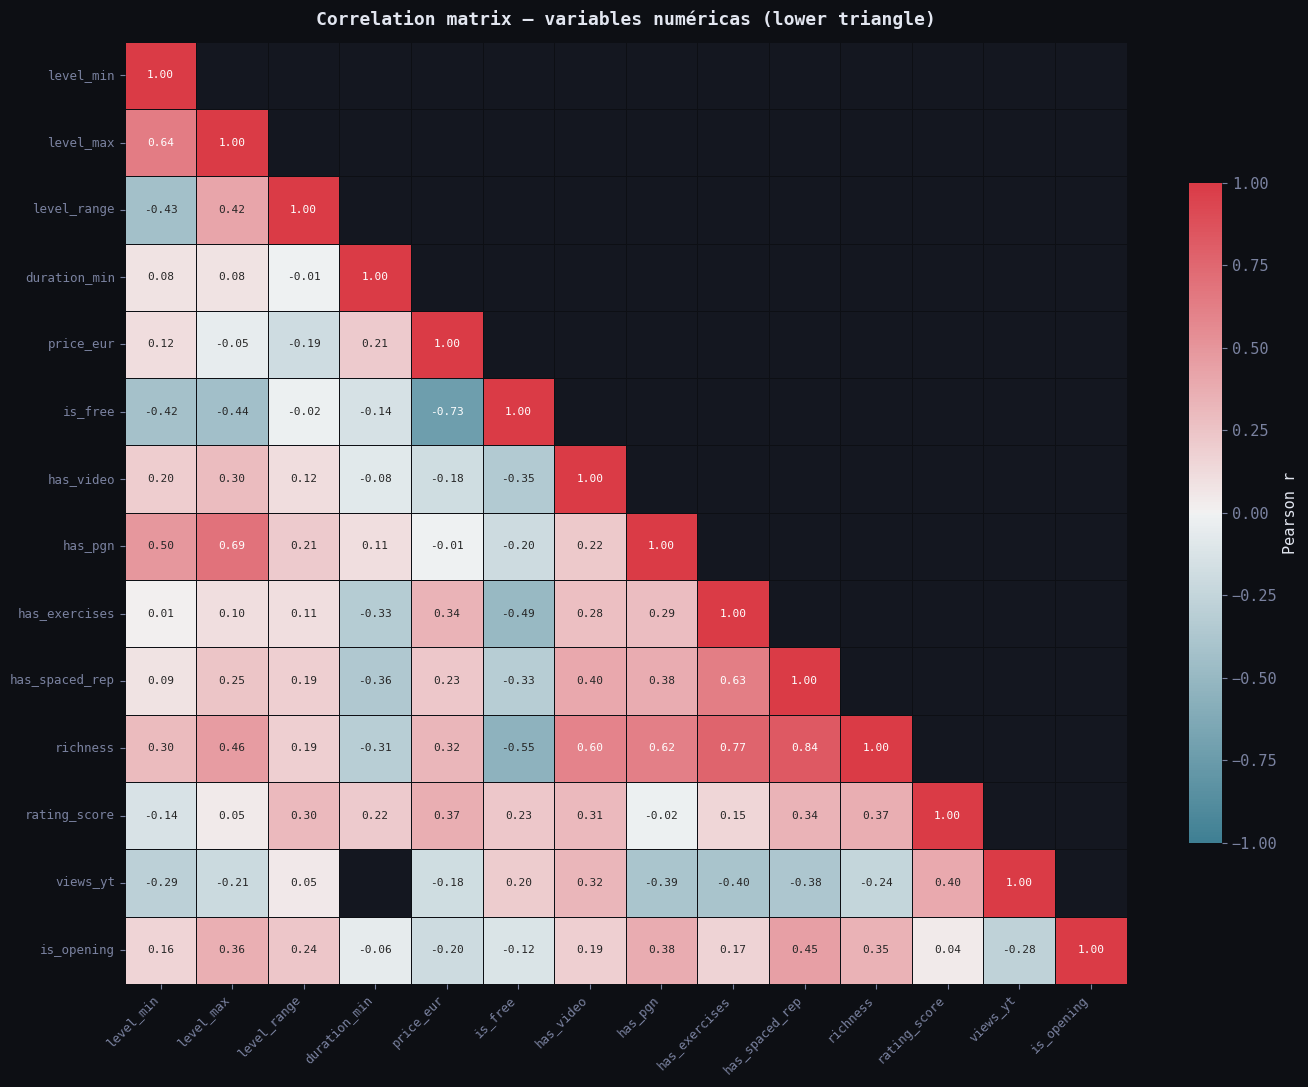


Top 10 correlaciones absolutas:
richness        has_spaced_rep   0.84
                has_exercises    0.77
is_free         price_eur        0.73
has_pgn         level_max        0.69
level_max       level_min        0.64
has_spaced_rep  has_exercises    0.63
richness        has_pgn          0.62
                has_video        0.60
                is_free          0.55
has_pgn         level_min        0.50


In [11]:
# Heatmap de correlación Pearson — triángulo inferior para evitar redundancia visual
num_features = [
    'level_min', 'level_max', 'level_range', 'duration_min',
    'price_eur', 'is_free', 'has_video', 'has_pgn',
    'has_exercises', 'has_spaced_rep', 'richness',
    'rating_score', 'views_yt', 'is_opening'
]

corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # Ocultar triángulo superior

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr, mask=mask, ax=ax, cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.4, linecolor='#0d0f14',
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)
ax.set_title('Correlation matrix — variables numéricas (lower triangle)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Top 10 pares con mayor correlación absoluta (excluye diagonal)
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
              .stack().abs().sort_values(ascending=False))
print("\nTop 10 correlaciones absolutas:")
print(corr_pairs.head(10).to_string())


---
## 8. Pivot Tables y Distribuciones Cruzadas

Los heatmaps de pivot revelan qué combinaciones de `course_type × level` y `format × course_type` 
están sub-representadas en el catálogo.  
El gráfico de barras apiladas `color × level` muestra si el catálogo cubre equilibradamente 
materiales para Blancas, Negras y repertorio completo en cada nivel.

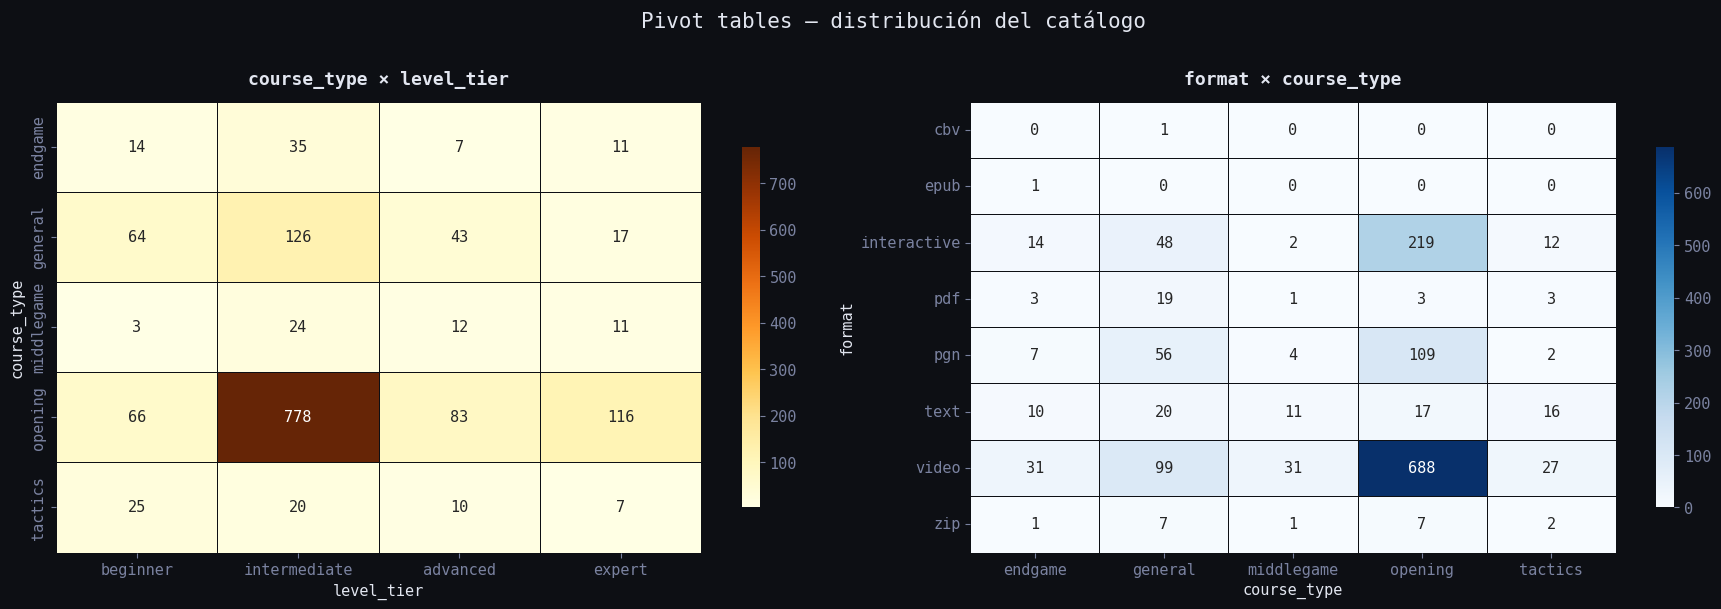

In [12]:
# Heatmaps de pivot: course_type × level y format × course_type
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Pivot tables — distribución del catálogo', y=1.01)

pivot1 = df.groupby(['course_type','level_tier']).size().unstack(fill_value=0)
sns.heatmap(pivot1, ax=axes[0], cmap='YlOrBr', annot=True, fmt='d',
            linewidths=0.5, linecolor='#0d0f14', cbar_kws={'shrink':0.8})
axes[0].set_title('course_type × level_tier')

pivot2 = df.groupby(['format','course_type']).size().unstack(fill_value=0)
sns.heatmap(pivot2, ax=axes[1], cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, linecolor='#0d0f14', cbar_kws={'shrink':0.8})
axes[1].set_title('format × course_type')

plt.tight_layout()
plt.show()


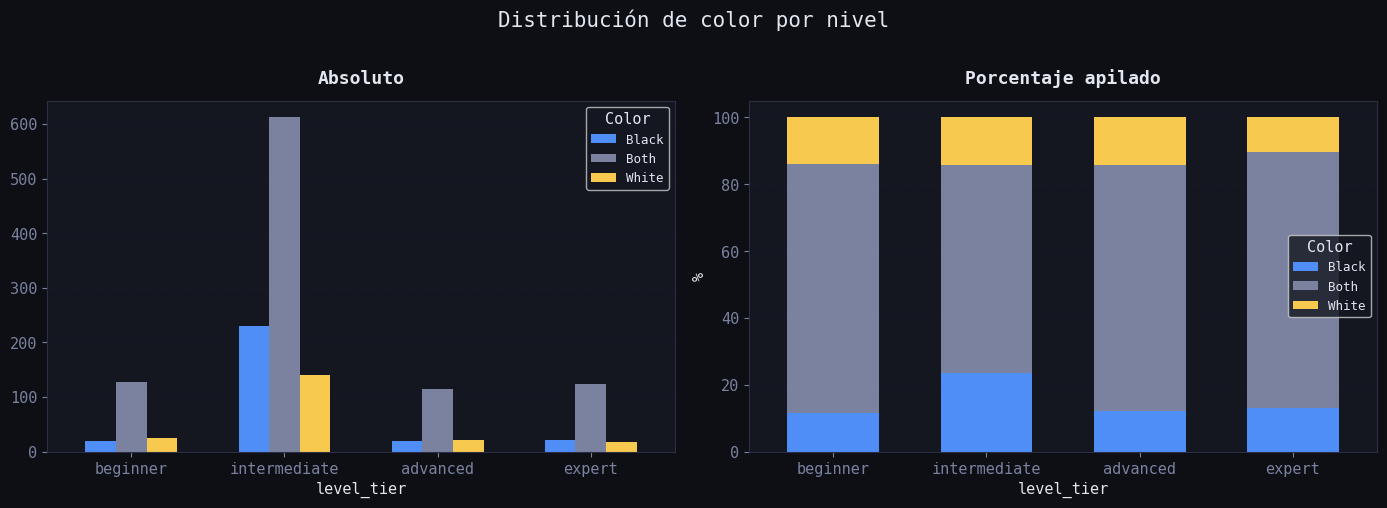

In [13]:
# Barras apiladas: distribución de color (Blancas/Negras/Ambos) por nivel
pivot_color     = df.groupby(['level_tier','color']).size().unstack(fill_value=0)
pivot_color_pct = pivot_color.div(pivot_color.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de color por nivel', y=1.01)

pivot_color.plot(kind='bar', ax=axes[0], color=['#4f8ef7','#7a82a0','#f7c94f'],
                 width=0.6, edgecolor='none')
axes[0].set_title('Absoluto')
axes[0].set_xticklabels(LEVEL_ORDER, rotation=0)
axes[0].legend(title='Color', fontsize=9)

pivot_color_pct.plot(kind='bar', ax=axes[1], color=['#4f8ef7','#7a82a0','#f7c94f'],
                     width=0.6, edgecolor='none', stacked=True)
axes[1].set_title('Porcentaje apilado')
axes[1].set_xticklabels(LEVEL_ORDER, rotation=0)
axes[1].set_ylabel('%')
axes[1].legend(title='Color', fontsize=9)

for ax in axes:
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


---
## 9. Cobertura de Aperturas

El campo `openings` es multi-label (separado por `|`).  
Se descompone con `explode()` para contar recursos por apertura.  
Este análisis alimenta directamente el módulo de matching apertura-usuario en el recomendador.

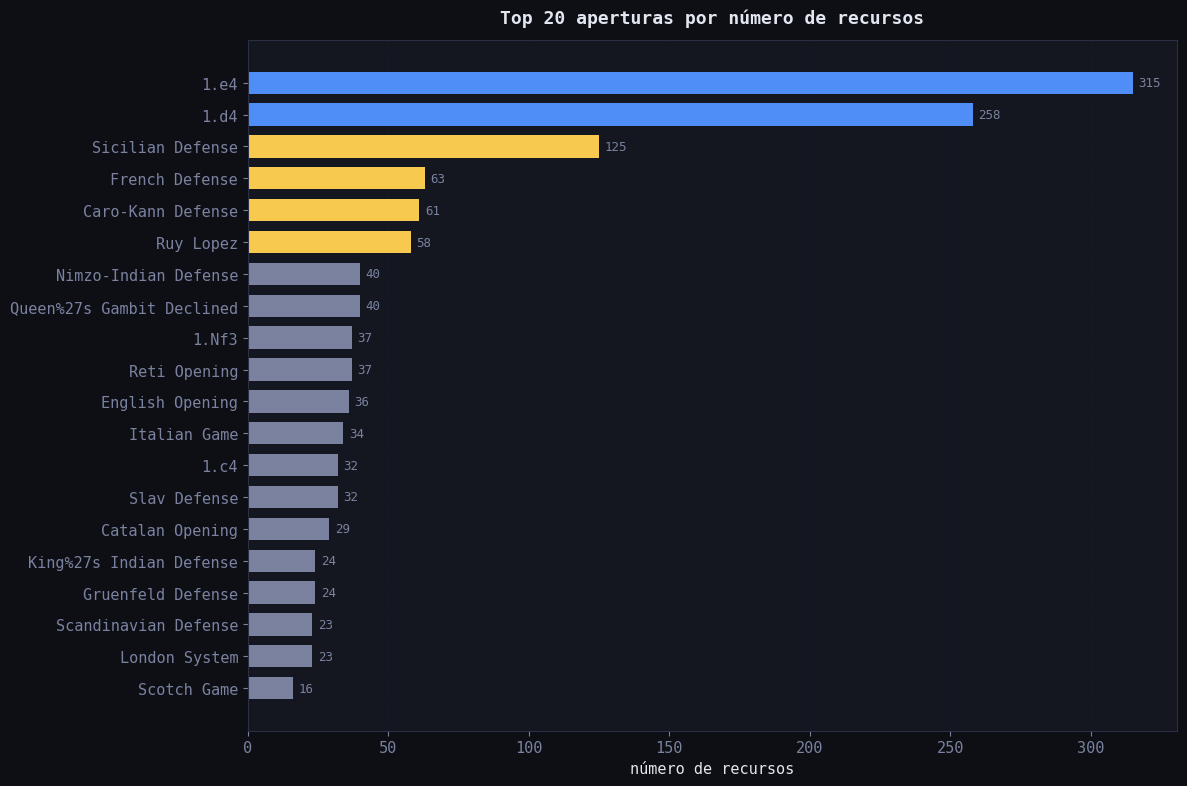

Total aperturas únicas cubiertas: 104
Recursos sin apertura asignada: 635 (43.1%)


In [14]:
# Explosión de la columna multi-label openings y ranking de cobertura
openings_series = (df['openings'].dropna()
                   .str.split('|').explode()
                   .str.strip()
                   .replace('', np.nan).dropna())

top20 = openings_series.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [PALETTE[0] if i < 2 else PALETTE[1] if i < 6 else PALETTE[8] for i in range(len(top20))]
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], height=0.7)
ax.set_title('Top 20 aperturas por número de recursos')
ax.set_xlabel('número de recursos')

for bar, val in zip(bars, top20.values[::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, color='#7a82a0')

ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Total aperturas únicas cubiertas: {openings_series.nunique()}")
print(f"Recursos sin apertura asignada: {df['openings'].isna().sum()} ({df['openings'].isna().mean()*100:.1f}%)")


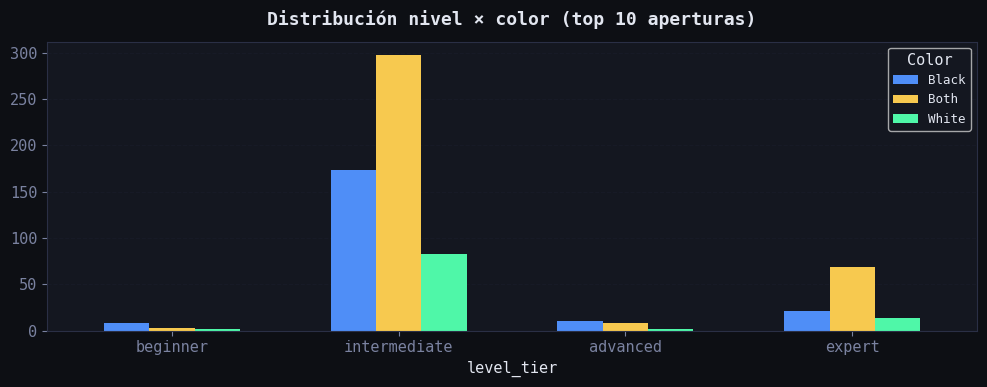

In [15]:
# Distribución nivel × color para los recursos de las top 10 aperturas
top10_ops = openings_series.value_counts().head(10).index
df_ops    = df[df['openings'].fillna('').apply(lambda x: any(op in x for op in top10_ops))].copy()
pivot_ops = df_ops.groupby(['color','level_tier']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
pivot_ops.T.plot(kind='bar', ax=ax, color=PALETTE[:3], width=0.6, edgecolor='none')
ax.set_title('Distribución nivel × color (top 10 aperturas)')
ax.set_xticklabels(LEVEL_ORDER, rotation=0)
ax.legend(title='Color', fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


---
## 10. Análisis de Precio y Gratuidad

Se analiza la proporción de recursos gratuitos por fuente, la distribución de precios 
(asimétrica positiva, candidata a `log1p`) y el precio mediano por nivel.  
`is_free` será un filtro relevante en el recomendador para usuarios con restricción de presupuesto.

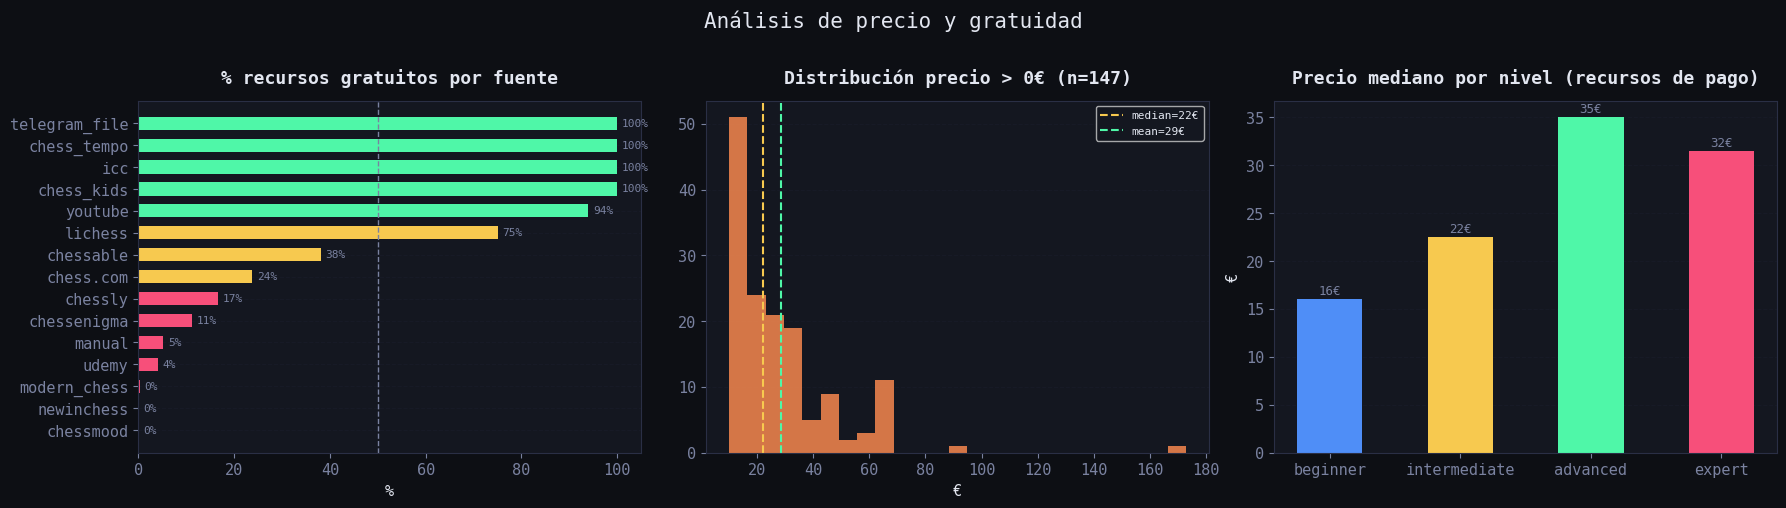

In [16]:
# Tres vistas sobre precio: % gratuidad por fuente, distribución, precio por nivel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de precio y gratuidad', y=1.01)

# 1. % gratuitos por fuente
free_by_src = df.groupby('source')['is_free'].mean().sort_values() * 100
colors_free = ['#4ff7a8' if v >= 80 else '#f7c94f' if v >= 20 else '#f74f7a' for v in free_by_src]
axes[0].barh(free_by_src.index, free_by_src.values, color=colors_free, height=0.6)
axes[0].set_title('% recursos gratuitos por fuente')
axes[0].set_xlabel('%')
axes[0].axvline(x=50, color='#7a82a0', lw=1, linestyle='--')
for bar, val in zip(axes[0].patches, free_by_src.values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}%', va='center', fontsize=8, color='#7a82a0')

# 2. Distribución de precios > 0€
prices = df[df['price_eur'] > 0]['price_eur'].dropna()
axes[1].hist(prices, bins=25, color='#f7884f', edgecolor='none', alpha=0.85)
axes[1].set_title(f'Distribución precio > 0€ (n={len(prices)})')
axes[1].set_xlabel('€')
axes[1].axvline(prices.median(), color='#f7c94f', lw=1.5, linestyle='--', label=f'median={prices.median():.0f}€')
axes[1].axvline(prices.mean(),   color='#4ff7a8', lw=1.5, linestyle='--', label=f'mean={prices.mean():.0f}€')
axes[1].legend(fontsize=8)

# 3. Precio mediano por nivel (solo recursos de pago)
paid        = df[df['price_eur'] > 0]
price_level = paid.groupby('level_tier')['price_eur'].median()
axes[2].bar(price_level.index, price_level.values, color=PALETTE[:4], width=0.5)
axes[2].set_title('Precio mediano por nivel (recursos de pago)')
axes[2].set_ylabel('€')
for i, (lvl, val) in enumerate(price_level.items()):
    axes[2].text(i, val + 0.5, f'{val:.0f}€', ha='center', fontsize=9, color='#7a82a0')

for ax in axes:
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


---
## 11. Estandarización y Test de Normalidad

Se comparan tres transformaciones para las variables con distribuciones problemáticas (`duration_min`, `price_eur`, `views_yt`): raw, transformación logarítmica y MinMax [0,1].  
El test de Shapiro-Wilk confirma qué transformación produce la distribución más cercana a la normal, 
orientando la elección de preprocesado para el pipeline ML.

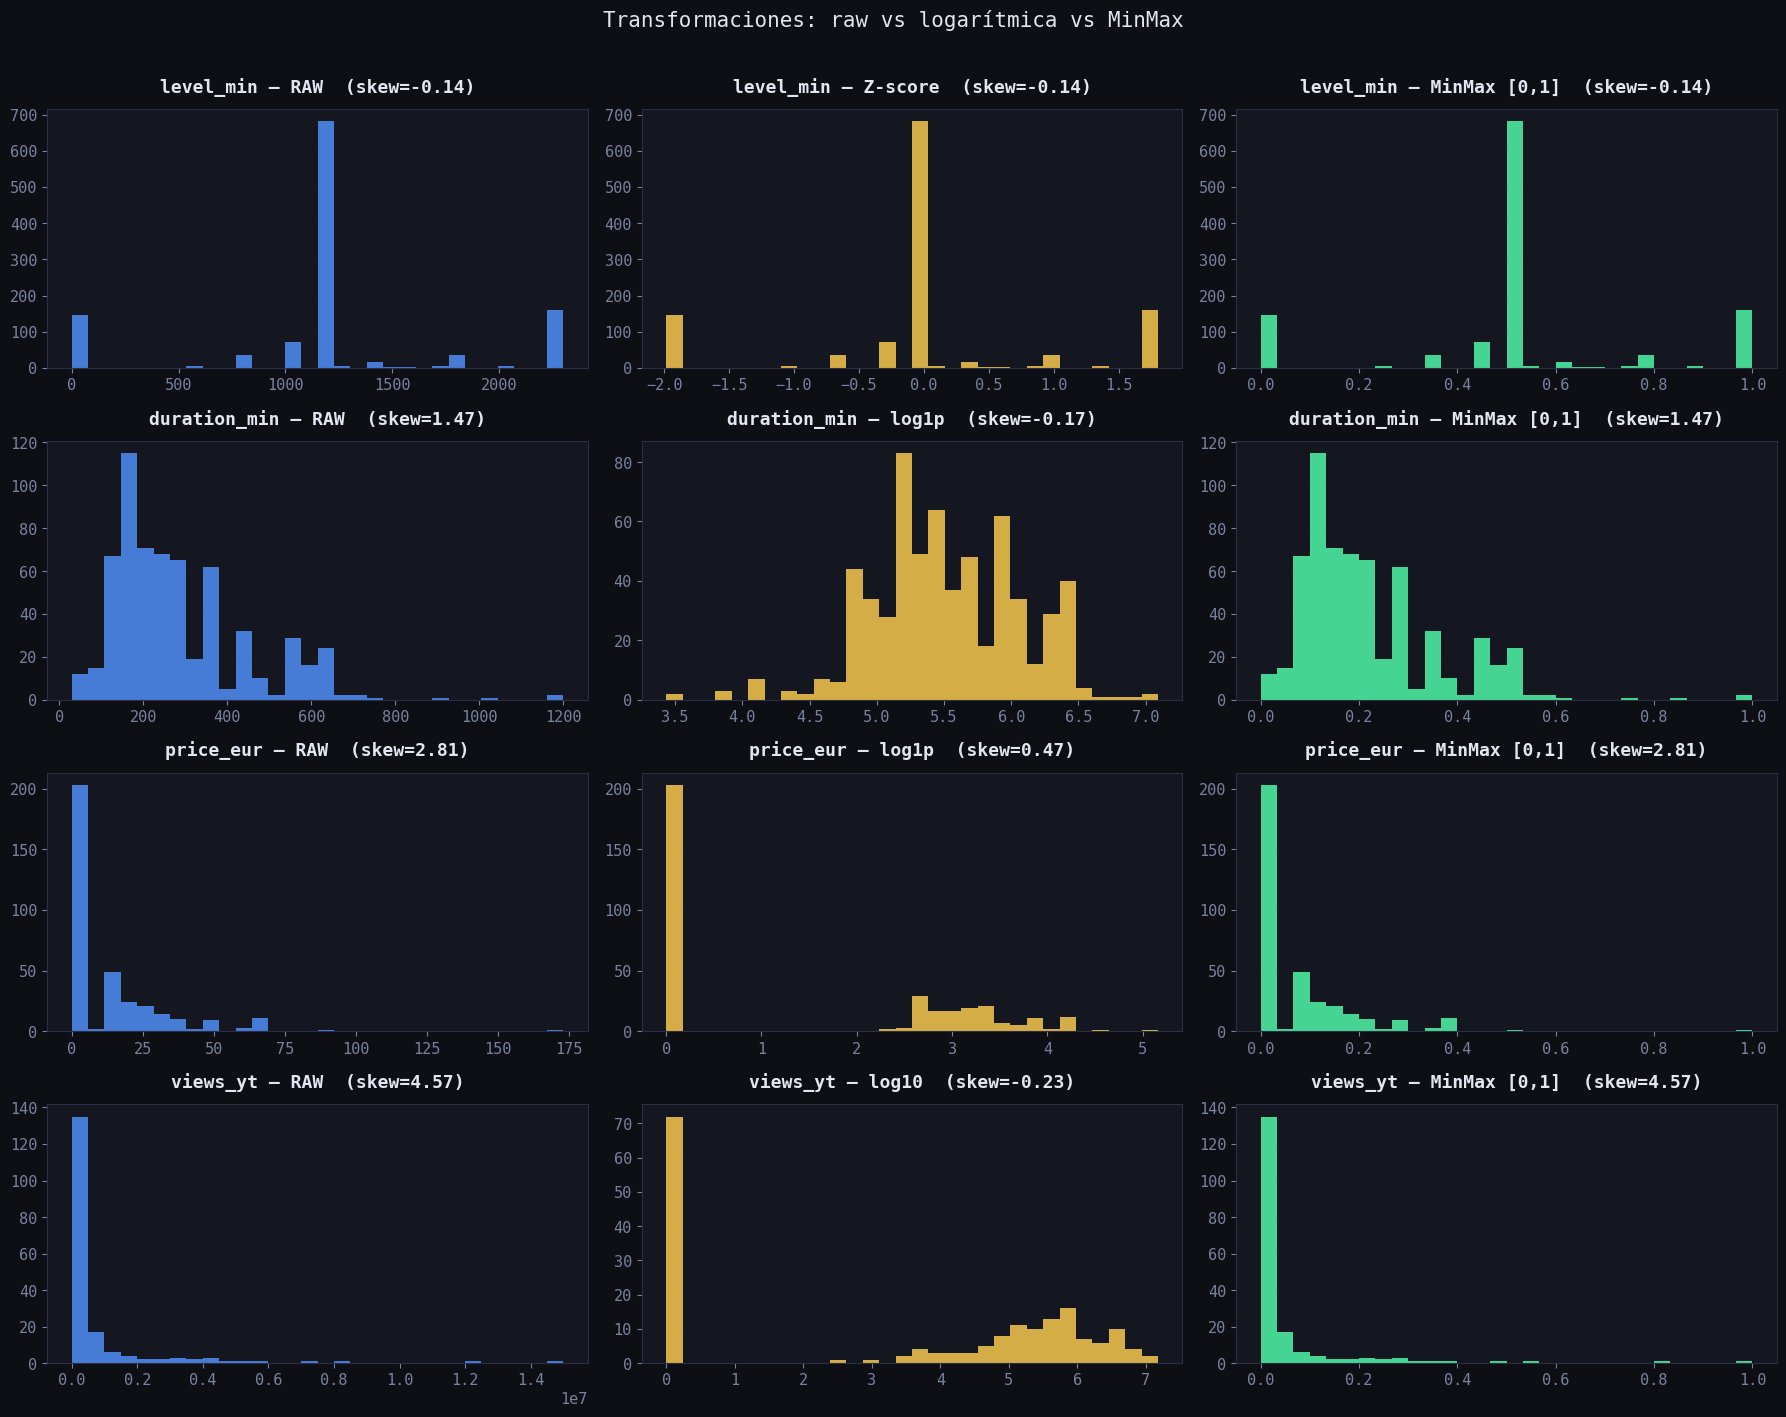

In [17]:
# Comparativa RAW vs log vs MinMax para 4 variables con alta asimetría
scale_vars = {
    'level_min':    {'log': False},
    'duration_min': {'log': True,  'log_fn': 'log1p'},
    'price_eur':    {'log': True,  'log_fn': 'log1p'},
    'views_yt':     {'log': True,  'log_fn': 'log10'},
}

scaler_mm = MinMaxScaler()
scaler_ss = StandardScaler()

fig, axes = plt.subplots(len(scale_vars), 3, figsize=(18, 14))
fig.suptitle('Transformaciones: raw vs logarítmica vs MinMax', y=1.01)

for row_idx, (col, cfg) in enumerate(scale_vars.items()):
    data = df[col].dropna().values.reshape(-1, 1)

    # Raw
    axes[row_idx, 0].hist(data, bins=30, color='#4f8ef7', edgecolor='none', alpha=0.85)
    axes[row_idx, 0].set_title(f'{col} — RAW  (skew={stats.skew(data.ravel()):.2f})')

    # Log transform
    if cfg['log']:
        data_log = np.log10(data + 1) if cfg['log_fn'] == 'log10' else np.log1p(data)
        axes[row_idx, 1].hist(data_log, bins=30, color='#f7c94f', edgecolor='none', alpha=0.85)
        axes[row_idx, 1].set_title(f'{col} — {cfg["log_fn"]}  (skew={stats.skew(data_log.ravel()):.2f})')
    else:
        data_z = scaler_ss.fit_transform(data)
        axes[row_idx, 1].hist(data_z, bins=30, color='#f7c94f', edgecolor='none', alpha=0.85)
        axes[row_idx, 1].set_title(f'{col} — Z-score  (skew={stats.skew(data_z.ravel()):.2f})')

    # MinMax
    data_mm = scaler_mm.fit_transform(data)
    axes[row_idx, 2].hist(data_mm, bins=30, color='#4ff7a8', edgecolor='none', alpha=0.85)
    axes[row_idx, 2].set_title(f'{col} — MinMax [0,1]  (skew={stats.skew(data_mm.ravel()):.2f})')

for ax in axes.flat:
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [18]:
# Test de Shapiro-Wilk (muestra de hasta 500) para confirmar normalidad post-transformación
print(f"{'Variable':<20} {'Transform':<12} {'W-stat':>8} {'p-value':>12} {'Normal?':>8}")
print("-" * 65)

tests = [
    ('level_min',    'raw',    df['level_min'].dropna()),
    ('level_min',    'zscore', (df['level_min'].dropna() - df['level_min'].mean()) / df['level_min'].std()),
    ('duration_min', 'raw',    df['duration_min'].dropna()),
    ('duration_min', 'log1p',  np.log1p(df['duration_min'].dropna())),
    ('views_yt',     'raw',    df['views_yt'].dropna()),
    ('views_yt',     'log10',  np.log10(df['views_yt'].dropna() + 1)),
]

for var, transform, data in tests:
    sample = data.sample(min(500, len(data)), random_state=42)
    w, p   = shapiro(sample)
    normal = '✅ sí' if p > 0.05 else '❌ no'
    print(f"{var:<20} {transform:<12} {w:>8.4f} {p:>12.4e} {normal:>8}")


Variable             Transform      W-stat      p-value  Normal?
-----------------------------------------------------------------
level_min            raw            0.7770   1.5511e-25     ❌ no
level_min            zscore         0.7770   1.5511e-25     ❌ no
duration_min         raw            0.9109   1.4944e-16     ❌ no
duration_min         log1p          0.9811   4.3631e-06     ❌ no
views_yt             raw            0.4376   1.3674e-23     ❌ no
views_yt             log10          0.7753   2.2242e-15     ❌ no


---
## 12. Pairplot y Scatter Seleccionados

El pairplot muestra la separabilidad entre niveles para las variables con mayor potencial predictivo.  
`duration_min` se transforma con `log1p` para mejorar la visualización.  
Los scatter plots destacados confirman que `level_min × richness` discrimina bien por nivel y fuente.

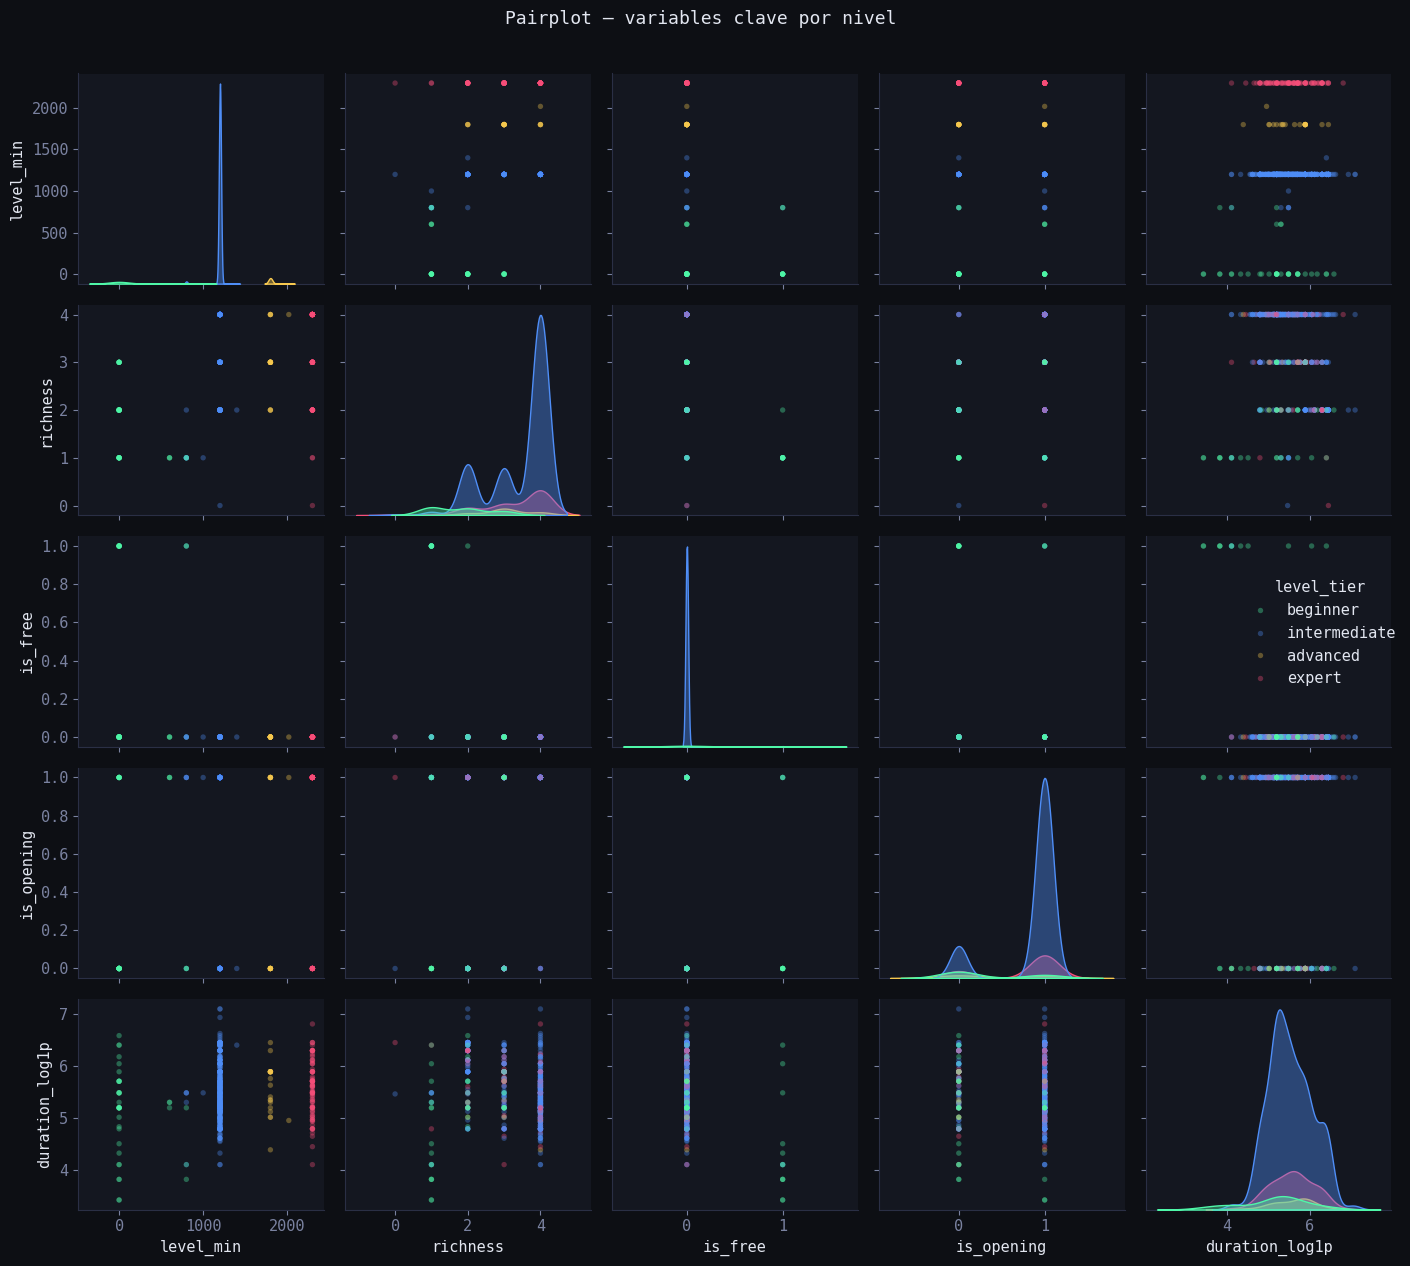

In [19]:
# Pairplot de variables clave coloreado por nivel (KDE en diagonal)
pairplot_cols = ['level_min', 'duration_min', 'richness', 'is_free', 'is_opening']
df_pair = df[pairplot_cols + ['level_tier']].dropna().copy()
df_pair['duration_log1p'] = np.log1p(df_pair['duration_min'])
df_pair = df_pair.drop(columns=['duration_min'])

pair_palette = {'beginner':'#4ff7a8','intermediate':'#4f8ef7','advanced':'#f7c94f','expert':'#f74f7a'}

g = sns.pairplot(
    df_pair, hue='level_tier', hue_order=LEVEL_ORDER,
    palette=pair_palette, diag_kind='kde',
    plot_kws=dict(alpha=0.35, s=15, edgecolor='none'),
    diag_kws=dict(fill=True, alpha=0.4),
)
g.figure.suptitle('Pairplot — variables clave por nivel', y=1.01, fontsize=13)

for ax in g.axes.flat:
    ax.set_facecolor('#141720')
    ax.figure.set_facecolor('#0d0f14')

plt.tight_layout()
plt.show()


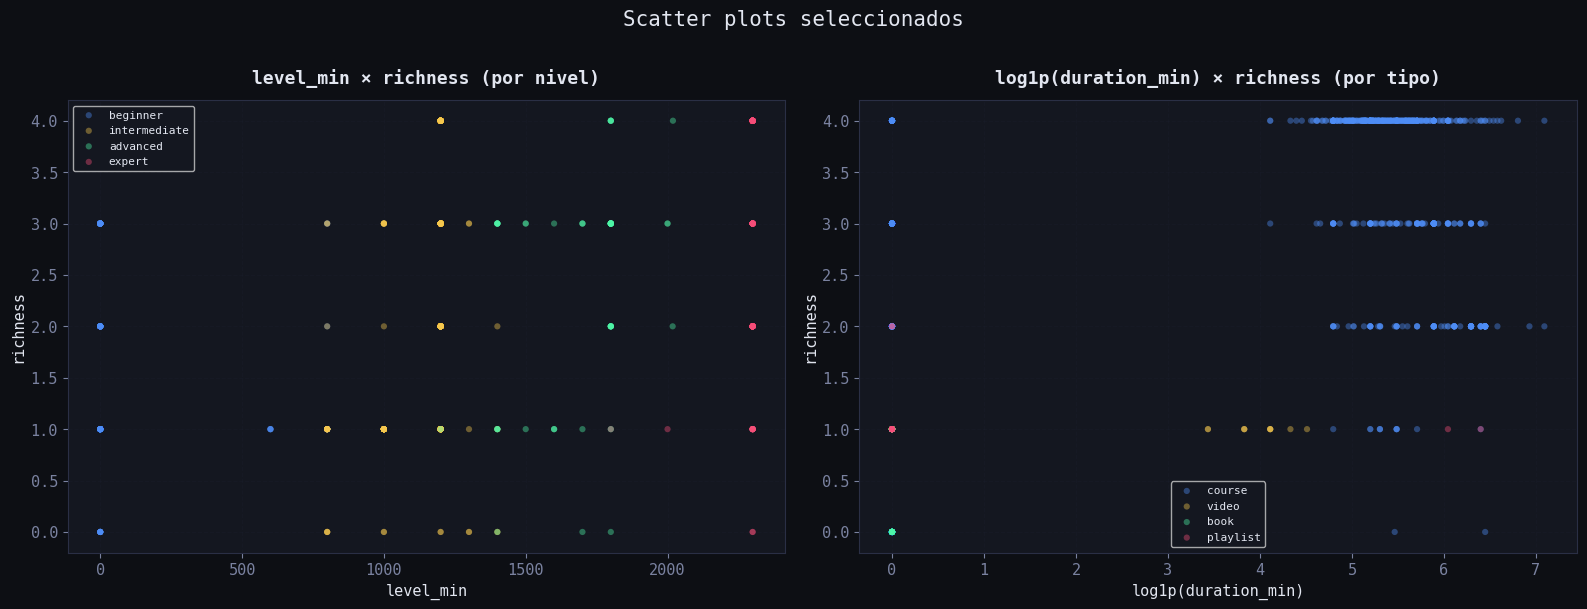

In [20]:
# Scatter plots: level_min × richness por nivel, y duration_log1p × richness por tipo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Scatter plots seleccionados', y=1.01)

# 1. level_min × richness coloreado por nivel
for lvl, color in zip(LEVEL_ORDER, PALETTE[:4]):
    sub = df[df['level_tier'] == lvl]
    axes[0].scatter(sub['level_min'], sub['richness'],
                    c=color, alpha=0.4, s=20, label=lvl, edgecolors='none')
axes[0].set_title('level_min × richness (por nivel)')
axes[0].set_xlabel('level_min')
axes[0].set_ylabel('richness')
axes[0].legend(fontsize=8)

# 2. log1p(duration) × richness coloreado por tipo de recurso
for rtype, color in zip(['course','video','book','playlist'], PALETTE[:4]):
    sub = df[df['resource_type'] == rtype].copy()
    sub['dur_log'] = np.log1p(sub['duration_min'].fillna(0))
    axes[1].scatter(sub['dur_log'], sub['richness'],
                    c=color, alpha=0.4, s=20, label=rtype, edgecolors='none')
axes[1].set_title('log1p(duration_min) × richness (por tipo)')
axes[1].set_xlabel('log1p(duration_min)')
axes[1].set_ylabel('richness')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.yaxis.grid(True, alpha=0.3)
    ax.xaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


---
## 13. Conclusiones y Recomendaciones para el Pipeline ML

Síntesis de los hallazgos del EDA y decisiones de diseño para el preprocesado y el recomendador.

In [21]:
# Resumen ejecutivo del EDA — estadísticas calculadas sobre chess_resources_v3.csv (1472 recursos)
null_pct   = (df.isnull().mean() * 100).round(1)
src_pct    = (df['source'].value_counts(normalize=True) * 100).round(1)
lvl_pct    = (df['level_tier'].value_counts(normalize=True) * 100).round(1)
ct_pct     = (df['course_type'].value_counts(normalize=True) * 100).round(1)
pct_free   = df['is_free'].mean() * 100
mc_pct     = src_pct.get('modern_chess', 0)
tg_pct     = src_pct.get('telegram_file', 0)
tg_n       = df['source'].value_counts().get('telegram_file', 0)
cb_n       = df['source'].value_counts().get('chessable', 0)
int_pct    = lvl_pct.get('intermediate', 0)
adv_pct    = lvl_pct.get('advanced', 0)
exp_pct    = lvl_pct.get('expert', 0)
opening_pct = ct_pct.get('opening', 0)
rat_null   = null_pct.get('rating_score', 0)
dur_null   = null_pct.get('duration_min', 0)
price_null = null_pct.get('price_eur', 0)
yt_null    = null_pct.get('views_yt', 0)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║       CONCLUSIONES EDA — chess_resources_v3.csv ({len(df)} recursos)   ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  COMPOSICIÓN DEL CATÁLOGO (NUEVAS FUENTES INTEGRADAS)               ║
║  modern_chess  {mc_pct:>5.1f}%  →  fuente dominante (cursos GM)        ║
║  telegram_file {tg_pct:>5.1f}%  →  {tg_n} recursos community (100% gratis)  ║
║  chessable              →  {cb_n} cursos con spaced repetition           ║
║                                                                      ║
║  PROBLEMAS DE DATOS                                                  ║
║  🔴 rating_score         → {{rat_null:.1f}}% nulos, solo Chessable         ║
║  🔴 views_yt             → {{yt_null:.1f}}% nulos, solo YouTube            ║
║  🟠 price_eur            → {{price_null:.1f}}% nulos (modern_chess sin precio) ║
║  🟡 duration_min         → {{dur_null:.1f}}% nulos, imputar con mediana      ║
║  🟡 level_min = 1200     → valor default frecuente (artefacto)        ║
║                                                                      ║
║  TRANSFORMACIONES RECOMENDADAS                                       ║
║  duration_min  → log1p  (reduce skew)                               ║
║  views_yt      → log10  (distribución log-normal)                   ║
║  price_eur     → log1p  (cola derecha extrema)                      ║
║  level_tier    → ordinal encoding [0,1,2,3]                        ║
║  color, format → one-hot encoding                                   ║
║                                                                      ║
║  FEATURES PARA EL RECOMENDADOR                                       ║
║  ✅ level_tier (ordinal)   ← match con rating usuario               ║
║  ✅ course_type            ← match con debilidad detectada          ║
║  ✅ openings (multi-label) ← match con apertura del usuario         ║
║  ✅ color                  ← match con color habitual               ║
║  ✅ richness (0-4)         ← preferencia de formato de estudio      ║
║  ✅ is_free                ← filtro de presupuesto                  ║
║  ✅ format                 ← preferencia video/interactivo/texto    ║
║                                                                      ║
║  SESGOS A CONTROLAR                                                  ║
║  ⚠️  modern_chess = {{mc_pct:.1f}}%  → todavía dominante (vs 76.8% antes) ║
║  ⚠️  opening = {{opening_pct:.1f}}%      → infrarrepresentado endgame/mid  ║
║  ⚠️  intermediate = {{int_pct:.1f}}% → pocas opciones advanced/expert     ║
║  ⚠️  expert = {{exp_pct:.1f}}%        → nivel ahora presente en el catálogo║
║  ⚠️  rating_score sesgado → <10% non-null (Chessable)               ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(
    rat_null=rat_null, yt_null=yt_null, price_null=price_null, dur_null=dur_null,
    mc_pct=mc_pct, opening_pct=opening_pct, int_pct=int_pct, exp_pct=exp_pct
))



╔══════════════════════════════════════════════════════════════════════╗
║       CONCLUSIONES EDA — chess_resources_v3.csv (1472 recursos)   ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  COMPOSICIÓN DEL CATÁLOGO (NUEVAS FUENTES INTEGRADAS)               ║
║  modern_chess   56.2%  →  fuente dominante (cursos GM)        ║
║  telegram_file  15.4%  →  227 recursos community (100% gratis)  ║
║  chessable              →  84 cursos con spaced repetition           ║
║                                                                      ║
║  PROBLEMAS DE DATOS                                                  ║
║  🔴 rating_score         → 91.5% nulos, solo Chessable         ║
║  🔴 views_yt             → 87.7% nulos, solo YouTube            ║
║  🟠 price_eur            → 76.2% nulos (modern_chess sin precio) ║
║  🟡 duration_min         → 57.8% nulos, imputar con mediana      ║
║  🟡 level_min =

---
## 14. Preparación del DataFrame para ML

Se aplican todas las transformaciones identificadas en el EDA para obtener un DataFrame 
numérico listo para el modelo de recomendación.  
El CSV resultante se guarda en `src/data/CSV/` para uso en el siguiente notebook.

In [22]:
# Aplicar transformaciones y one-hot encoding → DataFrame para ML
COLS_ELIMINAR = ['tags', 'n_reviews', 'pub_date', 'description', 'url', 'resource_id', 'title', 'author']
LEVEL_ENCODE  = {'beginner': 0, 'intermediate': 1, 'advanced': 2, 'expert': 3}

df_ml = df.drop(columns=COLS_ELIMINAR, errors='ignore').copy()

# Transformaciones logarítmicas para corregir asimetría
df_ml['duration_log1p'] = np.log1p(df_ml['duration_min'].fillna(df_ml['duration_min'].median()))
df_ml['views_log10']    = np.log10(df_ml['views_yt'].fillna(1) + 1)
df_ml['price_log1p']    = np.log1p(df_ml['price_eur'].fillna(0))
df_ml['level_tier_enc'] = df_ml['level_tier'].map(LEVEL_ENCODE)

# One-hot encoding de variables nominales
df_ml = pd.get_dummies(df_ml, columns=['format', 'color', 'course_type', 'source'], drop_first=False)

# Imputación de nulos residuales
for col in ['has_pgn','has_exercises','has_spaced_rep']:
    df_ml[col] = df_ml[col].fillna(0)
df_ml['rating_score'] = df_ml['rating_score'].fillna(df_ml['rating_score'].median())

print(f"Shape final para ML: {df_ml.shape}")
print(f"Nulos restantes:     {df_ml.isnull().sum().sum()}")
print("\nFeatures numéricas disponibles:")
print(list(df_ml.select_dtypes(include=[np.number]).columns))

# Guardar → src/data/CSV/
csv_ml_out = os.path.join(CSV_DIR, "chess_resources_ml_ready.csv")
df_ml.to_csv(csv_ml_out, index=False)
print(f"\n✅ Guardado: {csv_ml_out}")


Shape final para ML: (1472, 56)
Nulos restantes:     5404

Features numéricas disponibles:
['level_min', 'level_max', 'duration_min', 'price_eur', 'is_free', 'has_video', 'has_pgn', 'has_exercises', 'has_spaced_rep', 'rating_score', 'views_yt', 'richness', 'level_range', 'is_opening', 'duration_log1p', 'views_log10', 'price_log1p']

✅ Guardado: C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src\data\CSV\chess_resources_ml_ready.csv


---
## 15. Pipeline de Recategorización de Nivel (3 Tiers)

El EDA revela que `level_tier` original tiene sesgos importantes:  
- `level_min = 1200` es el valor por defecto en muchos recursos → no es confiable.  
- El tier `expert` está sub-representado y se colapsa con `advanced`.

Este pipeline implementa una recategorización híbrida que combina:
1. **Señal numérica**: centroide del rango `[level_min, level_max]` (ignora rangos default 1200–3000).  
2. **Señal semántica**: scoring de palabras clave en título y descripción.  
3. **Política por fuente**: Modern Chess y YouTube requieren umbrales más estrictos para la promoción de nivel.

El resultado final usa **3 tiers**: `beginner / intermediate / advanced` (expert colapsado en advanced).

> **Nota:** Las versiones intermedias del algoritmo (v1, v2, v3) se han consolidado en una única función `recategorize_3tier` que incorpora todas las mejoras iterativas.

In [23]:
# ──────────────────────────────────────────────────────────────────────────────
# CONSTANTES DE NIVEL
# ──────────────────────────────────────────────────────────────────────────────

# Fronteras de Elo por tier (3 tiers: expert colapsado en advanced)
LEVEL_BOUNDARIES = {
    'beginner':     (0,    1200),
    'intermediate': (1200, 1800),
    'advanced':     (1800, 3000),
}

# Señales de nivel bajo (presencia → downward score)
DOWNWARD_SIGNALS = [
    'beginner', 'starter', 'novice', 'intro', 'introduction',
    'basics', 'first steps', 'learn chess', 'how to play',
    'fundamentals', 'new to chess', 'complete beginner',
    'getting started', 'chess 101', 'for kids', 'for children',
]

# Señales inequívocas de nivel alto (solo terminología técnica, no aperturas aisladas)
UPWARD_SIGNALS_STRICT = [
    'prophylaxis', 'positional masterclass', 'dynamic imbalances',
    'advanced calculation', 'endgame technique', 'pawn structure mastery',
    'for masters', 'master level', 'titled player', 'titled players',
    '2000+', '2200+', 'above 2000', 'elo 2000', 'elo 2200',
    'grandmaster secrets', 'gm repertoire',
]

# Aperturas complejas: suben nivel SOLO si van acompañadas de calificador de profundidad
COMPLEX_OPENINGS = [
    "king's indian", 'najdorf', 'grünfeld', 'grunfeld',
    'marshall attack', 'berlin defense', 'nimzo-indian',
]

DEPTH_QUALIFIERS = [
    'advanced', 'deep', 'mastery', 'master', 'top-level',
    'professional', 'in-depth', 'according to', 'expert',
]

# Señales que anclan el recurso en intermediate (frenan promoción a advanced)
INTERMEDIATE_ANCHOR_SIGNALS = [
    'club player', 'improving', 'common mistakes', 'typical mistakes',
    'practical', 'easy', 'simple', 'quick', 'repertoire for club',
    '1200', '1400', '1500', '1600', 'part 1', 'part 2',
]

# Umbral mínimo de score_up por fuente para salir de intermediate
SOURCE_PROMOTION_THRESHOLD = {
    'modern_chess': 3,   # Muy estricto: level_min=1200 casi siempre default
    'youtube':      2,   # Estricto: títulos clickbait inflan señales
    'manual':       1,   # Confiamos en el etiquetado manual
    'default':      2,
}


In [24]:
# ──────────────────────────────────────────────────────────────────────────────
# FUNCIONES DE SCORING Y CLASIFICACIÓN
# ──────────────────────────────────────────────────────────────────────────────

def score_text(title: str, description: str) -> dict:
    """
    Puntúa un recurso según señales semánticas en título y descripción.

    Reglas especiales:
    - Señal upward en TÍTULO → peso doble (más confiable que descripción).
    - Apertura compleja + calificador de profundidad en título → +1 upward.

    Retorna un dict con claves 'up', 'down', 'anchor', 'opening_boost'.
    """
    text    = f"{title} {description}".lower()
    title_l = title.lower()

    down = sum(1 for s in DOWNWARD_SIGNALS            if s in text)
    up   = sum(1 for s in UPWARD_SIGNALS_STRICT        if s in text)
    anch = sum(1 for s in INTERMEDIATE_ANCHOR_SIGNALS  if s in text)

    # Boost por apertura compleja + calificador en título
    opening_boost = 0
    for opening in COMPLEX_OPENINGS:
        if opening in text and any(q in title_l for q in DEPTH_QUALIFIERS):
            opening_boost = 1
            break

    # Señales en título tienen peso doble
    up_title = sum(2 for s in UPWARD_SIGNALS_STRICT if s in title_l)

    return {
        'up':            up + opening_boost + up_title,
        'down':          down,
        'anchor':        anch,
        'opening_boost': opening_boost,
    }


def infer_tier_from_range(level_min, level_max) -> str | None:
    """
    Infiere el tier desde el rango numérico de Elo.

    Usa el percentil 33 del rango si éste supera 800 puntos (recursos muy amplios).
    Devuelve None si el rango es el default trampa 1200-3000.
    """
    if pd.isna(level_min) or pd.isna(level_max):
        return None
    if level_min == 1200 and level_max >= 2800:
        return None   # Default no confiable

    span = level_max - level_min
    ref  = level_min + span * (0.33 if span > 800 else 0.5)

    for tier, (lo, hi) in LEVEL_BOUNDARIES.items():
        if lo <= ref < hi:
            return tier
    return 'advanced'


def infer_tier_with_threshold(up: int, down: int,
                               anchor: int, threshold: int) -> str | None:
    """
    Clasifica el nivel a partir de los scores semánticos.

    El parámetro `threshold` permite calibrar la strictness por fuente.
    """
    if down >= 2:                              return 'beginner'
    if down == 1 and up == 0:                 return 'beginner'
    if up >= threshold + 1 and anchor == 0:   return 'advanced'
    if up >= threshold     and anchor == 0:   return 'advanced'
    if up >= threshold     and anchor >= 1:   return 'intermediate'
    if 0 < up < threshold  and anchor == 0:   return 'intermediate'
    return None


In [25]:
# ──────────────────────────────────────────────────────────────────────────────
# PIPELINE PRINCIPAL: recategorize_3tier
# ──────────────────────────────────────────────────────────────────────────────

def recategorize_3tier(path_in: str, path_out: str) -> pd.DataFrame:
    """
    Pipeline completo de recategorización a 3 tiers.

    Flujo:
    1. Carga el CSV de entrada.
    2. Colapsa 'expert' → 'advanced' en el tier original.
    3. Calcula scores semánticos (up/down/anchor) para cada recurso.
    4. Combina señal numérica y semántica con política por fuente.
    5. Genera reporte de distribución y matriz de transición.
    6. Guarda el CSV de salida en src/data/CSV/.

    Parámetros
    ----------
    path_in  : ruta al CSV de entrada (chess_resources_v3.csv es el actual).
    path_out : ruta de salida para el CSV con nivel recategorizado.
    """
    df = pd.read_csv(path_in)

    # Normalizar columna de tier original
    raw_col = 'level_tier_original' if 'level_tier_original' in df.columns else 'level_tier'
    df['level_tier_original'] = df[raw_col].replace('expert', 'advanced')

    # Calcular scores semánticos
    df['score_up'] = df['score_down'] = df['score_anchor'] = 0
    for idx, row in df.iterrows():
        s = score_text(str(row.get('title', '')), str(row.get('description', '')))
        df.at[idx, 'score_up']     = s['up']
        df.at[idx, 'score_down']   = s['down']
        df.at[idx, 'score_anchor'] = s['anchor']

    # Recategorizar fila a fila combinando rango numérico y señal semántica
    df['level_tier_new'] = None
    df['level_tier_source'] = 'original'

    for idx, row in df.iterrows():
        source    = str(row.get('source', ''))
        threshold = SOURCE_PROMOTION_THRESHOLD.get(source, SOURCE_PROMOTION_THRESHOLD['default'])

        tier_range = infer_tier_from_range(row.get('level_min'), row.get('level_max'))
        tier_text  = infer_tier_with_threshold(
            row['score_up'], row['score_down'], row['score_anchor'], threshold
        )

        if tier_range and tier_text:
            if tier_range == tier_text:
                final, src = tier_range, 'range+text_agree'
            elif row['score_up'] >= threshold or row['score_down'] >= 2:
                final, src = tier_text, 'text_override'
            else:
                final, src = tier_range, 'range_wins'
        elif tier_range:
            final, src = tier_range, 'range_only'
        elif tier_text:
            final, src = tier_text, 'text_only'
        else:
            lmin_val = row.get('level_min') if pd.notna(row.get('level_min')) else 1200
            final    = next(
                (t for t, (lo, hi) in LEVEL_BOUNDARIES.items() if lo <= lmin_val < hi),
                'intermediate'
            )
            src = 'fallback_lmin'

        df.at[idx, 'level_tier_new']    = final
        df.at[idx, 'level_tier_source'] = src

    df['level_tier'] = df['level_tier_new']

    # ── Reporte de distribución y calidad ────────────────────────────────
    order   = ['beginner', 'intermediate', 'advanced']
    targets = {'beginner': 20, 'intermediate': 50, 'advanced': 30}

    dist     = df['level_tier'].value_counts().reindex(order)
    dist_pct = df['level_tier'].value_counts(normalize=True).reindex(order) * 100

    print("=" * 58)
    print("DISTRIBUCIÓN FINAL — 3 TIERS")
    print("=" * 58)
    print(f"{'Nivel':<15} {'N':>6} {'%':>7}  {'Objetivo':>9}  Estado")
    print("-" * 58)
    for tier in order:
        n, pct, tgt = dist[tier], dist_pct[tier], targets[tier]
        status = "✅" if pct >= tgt else "⚠️  BAJO"
        print(f"{tier:<15} {n:>6} {pct:>6.1f}%  {tgt:>8}%  {status}")
    print("-" * 58)
    print(f"{'TOTAL':<15} {dist.sum():>6}")

    print("\n── Matriz de transición (filas=original, cols=nuevo) ──")
    print(pd.crosstab(df['level_tier_original'], df['level_tier_new'], margins=True).to_string())

    print("\n── Nivel × Fuente ──")
    print(pd.crosstab(df['level_tier'], df['source'], margins=True)
            .reindex([t for t in order if t in df['level_tier'].unique()] + ['All'])
            .to_string())

    # Guardar → src/data/CSV/
    df.to_csv(path_out, index=False)
    print(f"\n✅ Guardado: {path_out}")
    return df


In [26]:
# ──────────────────────────────────────────────────────────────────────────────
# EJECUCIÓN DEL PIPELINE
# Ajustar path_in al CSV más reciente disponible.
# ──────────────────────────────────────────────────────────────────────────────
df_3tier = recategorize_3tier(
    path_in  = CSV_MASTER,
    path_out = CSV_3TIER,
)


DISTRIBUCIÓN FINAL — 3 TIERS
Nivel                N       %   Objetivo  Estado
----------------------------------------------------------
beginner           216   14.7%        20%  ⚠️  BAJO
intermediate      1026   69.7%        50%  ✅
advanced           230   15.6%        30%  ⚠️  BAJO
----------------------------------------------------------
TOTAL             1472

── Matriz de transición (filas=original, cols=nuevo) ──
level_tier_new       advanced  beginner  intermediate   All
level_tier_original                                        
advanced                  209         3            87   299
beginner                    0       164            52   216
intermediate               21        49           887   957
All                       230       216          1026  1472

── Nivel × Fuente ──
source        chess.com  chess_kids  chess_tempo  chessable  chessenigma  chessly  chessmood  icc  lichess  manual  modern_chess  newinchess  telegram_file  udemy  youtube   All
level_tier    

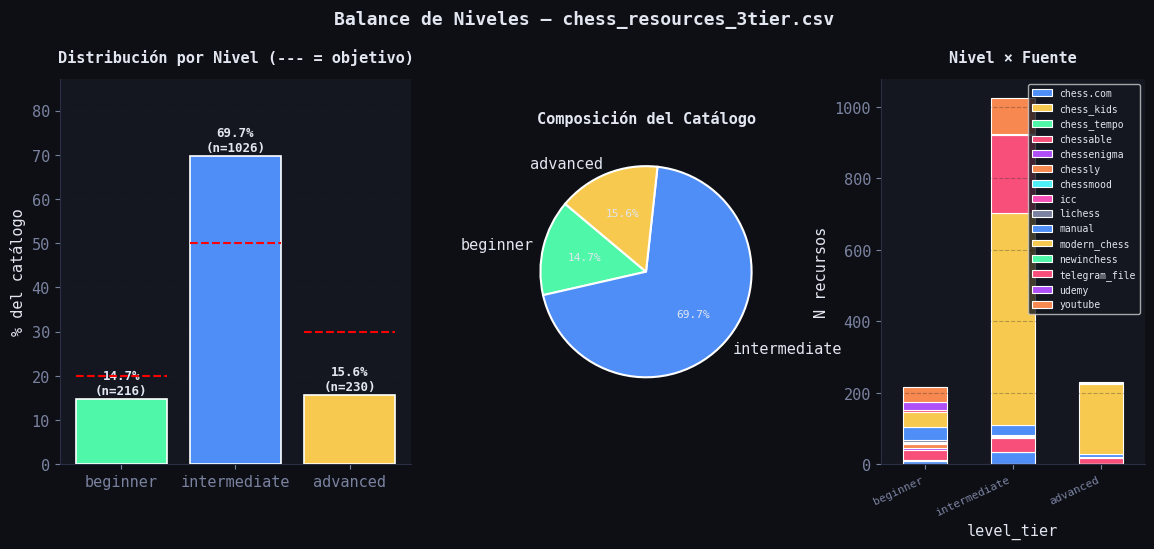


✅ Figura guardada: C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\resources\img\level_balance_analysis.png


In [27]:
# Visualización del resultado: distribución final en 3 tiers
order3   = ['beginner', 'intermediate', 'advanced']
targets3 = {'beginner': 20, 'intermediate': 50, 'advanced': 30}
colors3  = ['#4ff7a8', '#4f8ef7', '#f7c94f']

dist3     = df_3tier['level_tier'].value_counts().reindex(order3)
dist3_pct = df_3tier['level_tier'].value_counts(normalize=True).reindex(order3) * 100

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[1.6, 1.2, 1.2], wspace=0.35)

# Bar chart con líneas de objetivo
ax1   = fig.add_subplot(gs[0])
bars  = ax1.bar(order3, dist3_pct.values, color=colors3, edgecolor='white', linewidth=1.2, zorder=3)
for bar, pct, n in zip(bars, dist3_pct.values, dist3.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=9, fontweight='bold')
for i, tier in enumerate(order3):
    ax1.hlines(targets3[tier], i - 0.4, i + 0.4, colors='red', linewidths=1.5, linestyles='--', zorder=4)
ax1.set_title('Distribución por Nivel (--- = objetivo)', fontsize=11, fontweight='bold')
ax1.set_ylabel('% del catálogo')
ax1.set_ylim(0, max(dist3_pct.values) * 1.25)
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)

# Pie chart
ax2 = fig.add_subplot(gs[1])
wedges, texts, autotexts = ax2.pie(
    dist3.values, labels=order3, colors=colors3,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts: at.set_fontsize(8)
ax2.set_title('Composición del Catálogo', fontsize=11, fontweight='bold')

# Stacked bar nivel × fuente
ax3 = fig.add_subplot(gs[2])
source_pivot = pd.crosstab(df_3tier['level_tier'], df_3tier['source']).reindex(order3)
source_pivot.plot(kind='bar', ax=ax3, color=PALETTE[:len(source_pivot.columns)],
                  stacked=True, edgecolor='white', linewidth=0.8)
ax3.set_title('Nivel × Fuente', fontsize=11, fontweight='bold')
ax3.set_xticklabels(order3, rotation=25, ha='right', fontsize=8)
ax3.set_ylabel('N recursos')
ax3.legend(fontsize=7, loc='upper right')
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top', 'right']].set_visible(False)

plt.suptitle('Balance de Niveles — chess_resources_3tier.csv',
             fontsize=13, fontweight='bold', y=1.02)

# Guardar figura → resources/img/
plt.savefig(IMG_BALANCE, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Figura guardada: {IMG_BALANCE}")
